# PAG-Inspired Continuous Attractor Network

## Overview

This notebook implements a **minimal 2 × N continuous attractor network** inspired by
the defensive policy populations of the **Periaqueductal Gray (PAG)**.

The network has two rows and N columns:

| Axis | Meaning |
|------|---------|
| **Row 0 — Active** | Mobilising / approach-defence populations |
| **Row 1 — Passive** | Immobilising / modulatory populations |

Columns represent **relational distance to self**:

| # | Column | Meaning |
|---|--------|---------|
| 0 | Body / pain | Interoceptive / nociceptive |
| 1 | Peripersonal risk | Orienting / near-threat detection |
| 2 | World / escape | Flight, hide, freeze |
| 3 | Other-agent | Confrontation / submission |
| 4 | Social field | Vocalisation / social signalling |
| 5 | Panic / entrapment | Frantic escape / tonic immobility |

### What is NOT implemented here (yet)
- **Active Inference (AIF)** — the AIF layer will later modulate the bias matrix `b[r,i]`,
  the coupling terms (gamma, W_between, G, eta), and can read out posterior beliefs from
  the attractor states.  The placeholder `b[r,i]` is included and clearly labelled.
- Sensory input maps or motor output projections.

### References
- Canonical PAG column organisation: Bandler & Shipley (1994); Keay & Bandler (2001).
- Continuous attractor networks: Amari (1977); Seung (1996).

## 1 · Imports

In [1]:
!pip install numpy matplotlib scipy

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp

# Reproducibility
np.random.seed(42)

# Inline figures
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("Imports OK")


Imports OK


## 2 · Row and Column Definitions

Labels used throughout the notebook.  All numeric indices into the `(2, N)` arrays
correspond to these labels.

In [3]:
# ── Row indices ────────────────────────────────────────────────────────────────
ROW_ACTIVE  = 0   # mobilising / approach-defence populations
ROW_PASSIVE = 1   # immobilising / modulatory populations

ROW_LABELS = {
    ROW_ACTIVE:  "Active",
    ROW_PASSIVE: "Passive",
}

# ── Column indices ──────────────────────────────────────────────────────────────
COL_BODY       = 0   # Body / pain          – interoception / nociception
COL_PERI       = 1   # Peripersonal risk    – orienting / near-threat
COL_WORLD      = 2   # World / escape       – flight, hide, freeze
COL_OTHER      = 3   # Other-agent          – confrontation / submission
COL_SOCIAL     = 4   # Social field         – vocalisation / signalling
COL_PANIC      = 5   # Panic / entrapment   – frantic escape / tonic immobility

COL_LABELS = {
    COL_BODY:   "Body/pain",
    COL_PERI:   "Peripersonal risk",
    COL_WORLD:  "World/escape",
    COL_OTHER:  "Other-agent",
    COL_SOCIAL: "Social field",
    COL_PANIC:  "Panic/entrapment",
}

N_ROWS = 2        # number of rows (Active / Passive)
N      = 6        # number of columns

print("Rows :", list(ROW_LABELS.values()))
print("Cols :", list(COL_LABELS.values()))

Rows : ['Active', 'Passive']
Cols : ['Body/pain', 'Peripersonal risk', 'World/escape', 'Other-agent', 'Social field', 'Panic/entrapment']


## 3 · Parameters

All model hyperparameters live in a single `dict`.  They can be overridden locally
in each simulation cell without affecting the global defaults.

| Symbol | Name | Default | Role |
|--------|------|---------|------|
| `tau` | time constant | 1.0 | controls how fast states change |
| `alpha` | self-excitation | 1.4 | recurrent within-unit gain (center of center-surround) |
| `gamma` | within-column competition | 1.8 | active vs passive mutual inhibition |
| `lambda_between` | between-column inhibition | 0.7 | uniform global inhibition (surround of center-surround) |
| `eta` | compatibility gain | 0.6 | strength of cross-state synergy |
| `k` | sigmoid slope | 4.0 | non-linearity sharpness |
| `theta` | sigmoid threshold | per-column | activation midpoint (Panic = 0.75, others = 0.5) |
| `dt` | Euler step | 0.01 | integration time step |
| `T` | total time | 30.0 | simulation horizon |
| `noise` | noise level | 0.0 | optional stochastic term |

**v2 changes:** `sigma_w` removed (uniform inhibition replaces distance-dependent).
`theta` is now a vector (N,) with per-column values.

In [4]:
def default_params(N=6):
    """Return a dict of default model parameters.

    Parameters
    ----------
    N : int
        Number of columns (must match the column definitions).

    Returns
    -------
    dict

    Notes
    -----
    v2 changes:
    - sigma_w removed (uniform inhibition, no spatial decay)
    - theta is now a vector (N,) with per-column values
    - Panic column (index 5) has higher threshold (0.75)
    """
    # Per-column theta: Panic = 0.75, all others = 0.5
    theta = np.full(N, 0.5)
    if N >= 6:
        theta[5] = 0.75   # Panic/entrapment — higher threshold (Schenberg et al., 2001; Johnson et al., 2008)

    return dict(
        N          = N,
        tau        = 1.0,   # time constant
        alpha      = 1.4,   # recurrent self-excitation
        gamma      = np.full(N, 1.8),   # within-column competition (vector allows per-column tuning)
        lambda_between = 0.7,           # uniform between-column inhibition strength
        eta        = 0.6,   # cross-state compatibility gain
        k          = 4.0,   # sigmoid slope
        theta      = theta, # per-column sigmoid threshold
        dt         = 0.01,  # Euler integration step
        T          = 30.0,  # simulation horizon (time units)
        noise      = 0.0,   # optional Gaussian noise amplitude (0 = deterministic)

        # ── Bias matrix (2 × N) ─────────────────────────────────────────────
        # b[r, i] is an intrinsic bias / external drive placeholder.
        # AIF will later modulate these values; here they default to zero
        # (no external drive).  Override per-simulation as needed.
        b          = np.zeros((2, N)),
    )

PARAMS = default_params(N)
print("Default parameter dict:")
for k_name, v in PARAMS.items():
    print(f"  {k_name:20s}: {v}")

Default parameter dict:
  N                   : 6
  tau                 : 1.0
  alpha               : 1.4
  gamma               : [1.8 1.8 1.8 1.8 1.8 1.8]
  lambda_between      : 0.7
  eta                 : 0.6
  k                   : 4.0
  theta               : [0.5  0.5  0.5  0.5  0.5  0.75]
  dt                  : 0.01
  T                   : 30.0
  noise               : 0.0
  b                   : [[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


## 4 · Matrix Construction

### W_between — uniform global inhibition (v2)

$$W_{ij} = \begin{cases} 1 & \text{if } i \neq j \\ 0 & \text{if } i = j \end{cases}$$

**v2 change:** Replaced distance-dependent exponential kernel with uniform inhibition.
PAG columns are not spatially ordered — all competitive structure emerges from
self-excitation (alpha, center) and uniform inhibition (lambda, surround).

### G — compatibility / synergy tensor (v2: empty)

**v2 change:** All compatibility links disabled (G = 0). Starting from pure competition
to verify well-behaved attractor dynamics before incrementally reintroducing
neuroscience-justified links. See Section 12 for the planned reintroduction order.

In [5]:
def build_W_between(N: int, **kwargs) -> np.ndarray:
    """Build the between-column uniform global inhibition matrix.

    W[i, j] = 1 for i != j, 0 on diagonal.

    v2: replaced distance-dependent exponential with uniform inhibition.
    PAG columns are not spatially ordered; all structure comes from G.

    Parameters
    ----------
    N      : number of columns
    **kwargs : accepted for backward compatibility (sigma ignored)

    Returns
    -------
    W : (N, N) ndarray, all ones except zero diagonal
    """
    W = np.ones((N, N))
    np.fill_diagonal(W, 0.0)
    return W


def build_G(N: int) -> np.ndarray:
    """Build the compatibility / synergy tensor G.

    v2: returns an empty (all-zero) tensor.
    Starting from pure competition to verify clean attractor dynamics.
    G links will be reintroduced incrementally in Section 13+.

    Parameters
    ----------
    N : number of columns

    Returns
    -------
    G : (2, N, 2, N) ndarray of zeros
    """
    return np.zeros((2, N, 2, N), dtype=float)


# ── Build default matrices and store them in PARAMS ──────────────────────────
PARAMS["W_between"] = build_W_between(N)
PARAMS["G"]         = build_G(N)

# ── Quick sanity checks ──────────────────────────────────────────────────────
print("W_between (uniform, diagonal should be 0):")
print(np.round(PARAMS["W_between"], 3))

n_links = int(np.abs(PARAMS["G"]).sum())
print(f"\nG tensor shape : {PARAMS['G'].shape}")
print(f"Non-zero entries (compatibility links) : {n_links}  (expected 0 — v2 clean start)")

W_between (uniform, diagonal should be 0):
[[0. 1. 1. 1. 1. 1.]
 [1. 0. 1. 1. 1. 1.]
 [1. 1. 0. 1. 1. 1.]
 [1. 1. 1. 0. 1. 1.]
 [1. 1. 1. 1. 0. 1.]
 [1. 1. 1. 1. 1. 0.]]

G tensor shape : (2, 6, 2, 6)
Non-zero entries (compatibility links) : 0  (expected 0 — v2 clean start)


## 5 · Dynamics

### ODE

$$\tau \frac{dx_{r,i}}{dt} = -x_{r,i} + f\!\left[b_{r,i} + \alpha\, x_{r,i} - \gamma_i\, x_{\bar{r},i} - \lambda_{\text{btw}} \sum_{j \neq i} W_{ij}\, x_{r,j} + \eta \sum_{s,j} G_{r,i,s,j}\, x_{s,j}\right]$$

where $\bar{r}$ is the opposite row, and $f(z) = \bigl(1 + e^{-k(z-\theta)}\bigr)^{-1}$.

### Functions

| Function | Purpose |
|---|---|
| `sigmoid(z, k, theta)` | bounded non-linearity |
| `rhs(x_flat, t, params)` | ODE right-hand side (flat array interface for `solve_ivp`) |
| `step_euler(x, params, dt)` | single Euler step, clips to `[0, 1]` |
| `simulate(x0, params, T, dt, bias_schedule)` | full simulation, Euler by default |

In [6]:
# ── Activation function ───────────────────────────────────────────────────────

def sigmoid(z: np.ndarray, k: float, theta) -> np.ndarray:
    """Element-wise sigmoid:  1 / (1 + exp(-k*(z - theta))).

    Numerically safe via np.clip to prevent overflow.

    Parameters
    ----------
    z     : input array (any shape)
    k     : slope parameter (scalar)
    theta : threshold — scalar or array broadcastable with z
    """
    return 1.0 / (1.0 + np.exp(-k * np.clip(z - theta, -50, 50)))


# ── Right-hand side of the ODE ────────────────────────────────────────────────

def rhs(x: np.ndarray, params: dict, b_override: np.ndarray | None = None) -> np.ndarray:
    """Compute dx/dt for a (2, N) state array x.

    Parameters
    ----------
    x          : (2, N) state array, values expected in [0, 1]
    params     : parameter dict (from default_params())
    b_override : optional (2, N) bias array; overrides params["b"] if given

    Returns
    -------
    dxdt : (2, N) array
    """
    N               = params["N"]
    tau             = params["tau"]
    alpha           = params["alpha"]
    gamma           = params["gamma"]          # (N,) vector
    lam             = params["lambda_between"]
    eta             = params["eta"]
    k               = params["k"]
    theta           = params["theta"]          # scalar or (N,) vector
    W               = params["W_between"]      # (N, N)
    G               = params["G"]              # (2, N, 2, N)
    b               = b_override if b_override is not None else params["b"]  # (2, N)

    dxdt = np.zeros((2, N))

    for r in range(2):
        opp = 1 - r   # opposite row index

        # Recurrent self-excitation: alpha * x[r, :]
        self_exc = alpha * x[r, :]

        # Within-column competition: gamma_i * x[opposite_row, i]
        within_comp = gamma * x[opp, :]

        # Between-column inhibition: lambda * sum_{j!=i} W[i,j] * x[r, j]
        # W has zero diagonal, so we can do the full matrix product.
        between_inh = lam * (W @ x[r, :])

        # Compatibility synergy: eta * sum_{s,j} G[r,i,s,j] * x[s,j]
        # G[r, :, :, :] has shape (N, 2, N); reshape x to (2*N,) and G[r] to (N, 2*N).
        G_r = G[r].reshape(N, 2 * N)   # (N, 2*N)
        x_flat = x.reshape(2 * N)       # (2*N,)
        compat = eta * (G_r @ x_flat)   # (N,)

        # Pre-synaptic input
        z = b[r, :] + self_exc - within_comp - between_inh + compat

        # ODE: tau * dx/dt = -x + f(z)
        # theta broadcasts: scalar applies uniformly, vector (N,) applies per-column
        dxdt[r, :] = (-x[r, :] + sigmoid(z, k, theta)) / tau

    return dxdt


# ── Single Euler step ─────────────────────────────────────────────────────────

def step_euler(
    x: np.ndarray,
    params: dict,
    dt: float,
    b_override: np.ndarray | None = None,
) -> np.ndarray:
    """Advance x by one Euler step and clip to [0, 1].

    Parameters
    ----------
    x          : (2, N) current state
    params     : parameter dict
    dt         : time step
    b_override : optional (2, N) bias override

    Returns
    -------
    x_new : (2, N) updated state, clipped to [0, 1]
    """
    noise_amp = params.get("noise", 0.0)
    dx = rhs(x, params, b_override=b_override) * dt
    if noise_amp > 0.0:
        dx += noise_amp * np.random.randn(*x.shape) * np.sqrt(dt)
    return np.clip(x + dx, 0.0, 1.0)


# ── Full simulation ───────────────────────────────────────────────────────────

def simulate(
    x0: np.ndarray,
    params: dict,
    T: float | None = None,
    dt: float | None = None,
    bias_schedule=None,
) -> tuple[np.ndarray, np.ndarray]:
    """Simulate the attractor network from initial state x0.

    Parameters
    ----------
    x0            : (2, N) initial state array
    params        : parameter dict
    T             : total simulation time (overrides params["T"] if given)
    dt            : time step (overrides params["dt"] if given)
    bias_schedule : callable(t) -> (2, N) array, or None.
                    If None, params["b"] is used throughout.

    Returns
    -------
    t_vec : (n_steps,) time vector
    traj  : (n_steps, 2, N) trajectory array
    """
    T  = T  if T  is not None else params["T"]
    dt = dt if dt is not None else params["dt"]

    n_steps = int(np.round(T / dt))
    t_vec   = np.linspace(0.0, T, n_steps)
    traj    = np.empty((n_steps, 2, params["N"]))

    x = x0.copy().astype(float)
    traj[0] = x

    for step in range(1, n_steps):
        t_now = t_vec[step]
        b_now = bias_schedule(t_now) if bias_schedule is not None else None
        x = step_euler(x, params, dt, b_override=b_now)
        traj[step] = x

    return t_vec, traj


print("Dynamics functions defined: sigmoid, rhs, step_euler, simulate")

Dynamics functions defined: sigmoid, rhs, step_euler, simulate


### Quick smoke-test

Verify that `rhs` returns the right shape and that `simulate` completes without errors on a trivial initial condition.

In [7]:
# ── Smoke test ───────────────────────────────────────────────────────────────
_params_test = default_params(N)
_params_test["W_between"] = build_W_between(N)
_params_test["G"]         = build_G(N)

# Random initial state in [0, 1]
_x0_test = np.random.rand(2, N) * 0.1

# Single rhs call
_dxdt = rhs(_x0_test, _params_test)
assert _dxdt.shape == (2, N), f"rhs shape mismatch: {_dxdt.shape}"

# Short simulation (T=1 to keep it fast)
_t, _traj = simulate(_x0_test, _params_test, T=1.0)
assert _traj.shape[1:] == (2, N), f"traj shape mismatch: {_traj.shape}"
assert np.all(_traj >= 0.0) and np.all(_traj <= 1.0), "values outside [0,1]!"

print(f"rhs output shape  : {_dxdt.shape}  ✓")
print(f"traj shape        : {_traj.shape}  ✓")
print(f"values in [0,1]   : {np.all((_traj >= 0) & (_traj <= 1))}  ✓")
print(f"theta             : {_params_test['theta']}  (Panic at 0.75)")

rhs output shape  : (2, 6)  ✓
traj shape        : (100, 2, 6)  ✓
values in [0,1]   : True  ✓
theta             : [0.5  0.5  0.5  0.5  0.5  0.75]  (Panic at 0.75)


## 6 · Visualization Helpers

Reusable plotting functions used by all simulation cells below.

In [8]:
_ROW_COLORS = {ROW_ACTIVE: "#e05a3a", ROW_PASSIVE: "#3a7de0"}
_COL_COLORS = ["#7b68ee", "#5b9bd5", "#70ad47", "#ed7d31", "#a5a5a5", "#c44e52"]


# ─────────────────────────────────────────────────────────────────────────────
# 1. Time-series of each population
# ─────────────────────────────────────────────────────────────────────────────

def plot_activity_timeseries(
    t: np.ndarray,
    traj: np.ndarray,
    row_labels: dict = ROW_LABELS,
    col_labels: dict = COL_LABELS,
    title: str = "Population activity over time",
) -> None:
    """Plot one subplot per row (Active / Passive), one line per column.

    Parameters
    ----------
    t          : (n_steps,) time vector
    traj       : (n_steps, 2, N) trajectory
    row_labels : dict mapping row index to name
    col_labels : dict mapping col index to name
    title      : figure title
    """
    n_rows = traj.shape[1]
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, 3 * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]

    for r, ax in enumerate(axes):
        for i in range(traj.shape[2]):
            ax.plot(t, traj[:, r, i], lw=2,
                    color=_COL_COLORS[i % len(_COL_COLORS)],
                    label=col_labels.get(i, str(i)))
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel("Activity")
        ax.set_title(f"{row_labels.get(r, str(r))} populations")
        ax.legend(loc="upper right", fontsize=9, ncol=2)

    axes[-1].set_xlabel("Time")
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 2. Heatmap of final state
# ─────────────────────────────────────────────────────────────────────────────

def plot_final_state_heatmap(
    x_final: np.ndarray,
    row_labels: dict = ROW_LABELS,
    col_labels: dict = COL_LABELS,
    title: str = "Final state",
) -> None:
    """2 × N heatmap of the final attractor state."""
    fig, ax = plt.subplots(figsize=(8, 2.0))
    im = ax.imshow(x_final, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(x_final.shape[1]))
    ax.set_xticklabels([col_labels.get(i, str(i)) for i in range(x_final.shape[1])],
                       rotation=30, ha="right")
    ax.set_yticks(range(x_final.shape[0]))
    ax.set_yticklabels([row_labels.get(r, str(r)) for r in range(x_final.shape[0])])
    plt.colorbar(im, ax=ax, label="Activity")
    ax.set_title(title, fontweight="bold")
    # annotate cell values
    for r in range(x_final.shape[0]):
        for i in range(x_final.shape[1]):
            ax.text(i, r, f"{x_final[r, i]:.2f}", ha="center", va="center",
                    fontsize=9, color="white" if x_final[r, i] > 0.6 else "black")
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 3. Heatmap over time (space-time plot)
# ─────────────────────────────────────────────────────────────────────────────

def plot_state_heatmap_over_time(
    t: np.ndarray,
    traj: np.ndarray,
    row_labels: dict = ROW_LABELS,
    col_labels: dict = COL_LABELS,
    title: str = "Activity over time",
    downsample: int = 4,
) -> None:
    """Show activity as a colour-coded (time × column) image for each row.

    Parameters
    ----------
    downsample : plot every nth time step to keep the image manageable
    """
    n_rows = traj.shape[1]
    n_cols = traj.shape[2]
    t_ds   = t[::downsample]
    tr_ds  = traj[::downsample]

    fig, axes = plt.subplots(1, n_rows, figsize=(6 * n_rows, 4))
    if n_rows == 1:
        axes = [axes]

    for r, ax in enumerate(axes):
        im = ax.imshow(
            tr_ds[:, r, :].T,        # (N, time) so columns are y, time is x
            origin="lower",
            aspect="auto",
            extent=[t_ds[0], t_ds[-1], -0.5, n_cols - 0.5],
            vmin=0, vmax=1,
            cmap="RdYlGn",
        )
        ax.set_xlabel("Time")
        ax.set_yticks(range(n_cols))
        ax.set_yticklabels([col_labels.get(i, str(i)) for i in range(n_cols)])
        ax.set_title(f"{row_labels.get(r, str(r))}", fontweight="bold")
        plt.colorbar(im, ax=ax, label="Activity")

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 4. Phase plane for a single column (Active vs Passive)
# ─────────────────────────────────────────────────────────────────────────────

def plot_phase_plane_for_column(
    t: np.ndarray,
    traj: np.ndarray,
    column_index: int,
    col_labels: dict = COL_LABELS,
    title: str | None = None,
) -> None:
    """Plot Active vs Passive activity for one column as a trajectory.

    The colour of the line encodes time (dark = early, bright = late).
    """
    active  = traj[:, ROW_ACTIVE,  column_index]
    passive = traj[:, ROW_PASSIVE, column_index]
    col_name = col_labels.get(column_index, str(column_index))
    title    = title or f"Phase plane — {col_name}"

    t_norm = (t - t.min()) / (t.max() - t.min() + 1e-12)
    cmap   = plt.get_cmap("plasma")

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    for i in range(len(t) - 1):
        ax.plot(active[i:i+2], passive[i:i+2], lw=1.5,
                color=cmap(t_norm[i]), alpha=0.85)

    # Mark start and end
    ax.scatter([active[0]],  [passive[0]],  s=80, color="green",  zorder=5, label="start")
    ax.scatter([active[-1]], [passive[-1]], s=80, color="red",    zorder=5, label="end")

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Active")
    ax.set_ylabel("Passive")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=t.min(), vmax=t.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Time")
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 5. Network diagram
# ─────────────────────────────────────────────────────────────────────────────

def plot_network_diagram(
    W_between: np.ndarray,
    G: np.ndarray,
    col_labels: dict = COL_LABELS,
    row_labels: dict = ROW_LABELS,
    w_threshold: float = 0.1,
    title: str = "Network connectivity diagram",
) -> None:
    """Draw nodes (Active/Passive × N columns) and connections.

    - Grey dashed lines = W_between inhibitory links (above threshold)
    - Coloured solid lines = G compatibility links
    """
    N      = W_between.shape[0]
    n_rows = 2

    # Node positions: row r, column i → (x, y) = (i, -r * 2)
    def pos(r, i):
        return (i * 1.5, -r * 2.5)

    fig, ax = plt.subplots(figsize=(N * 1.8, 5))
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontweight="bold", fontsize=12)

    # Draw W_between inhibitory edges (within same row, symmetric → draw once)
    for r in range(n_rows):
        for i in range(N):
            for j in range(i + 1, N):
                w = W_between[i, j]
                if w > w_threshold:
                    x0, y0 = pos(r, i)
                    x1, y1 = pos(r, j)
                    ax.plot([x0, x1], [y0, y1], color="gray", lw=w * 2,
                            alpha=0.4, linestyle="--", zorder=1)

    # Draw G compatibility edges
    g_color = "#27ae60"
    src_indices = list(zip(*np.where(G > 0)))  # (tgt_r, tgt_i, src_r, src_i)
    for (tgt_r, tgt_i, src_r, src_i) in src_indices:
        x0, y0 = pos(src_r, src_i)
        x1, y1 = pos(tgt_r, tgt_i)
        # Offset slightly to distinguish bidirectional links
        offset = 0.08
        ax.annotate(
            "", xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(
                arrowstyle="->", color=g_color, lw=1.6,
                connectionstyle=f"arc3,rad={offset}",
            ),
            zorder=2,
        )

    # Draw nodes
    for r in range(n_rows):
        for i in range(N):
            x, y = pos(r, i)
            circle = plt.Circle((x, y), 0.38,
                                 color=_ROW_COLORS[r], zorder=3, alpha=0.85)
            ax.add_patch(circle)
            ax.text(x, y, col_labels.get(i, str(i)).replace(" ", "\n"),
                    ha="center", va="center", fontsize=6.5,
                    color="white", fontweight="bold", zorder=4)

    # Row labels on the left
    for r in range(n_rows):
        _, y = pos(r, -0.6)
        ax.text(-1.1, y, row_labels.get(r, str(r)),
                ha="right", va="center", fontsize=10, color=_ROW_COLORS[r],
                fontweight="bold")

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="gray",   linestyle="--", lw=2, label="W_between (inhibitory)"),
        Line2D([0], [0], color=g_color,  linestyle="-",  lw=2, label="G (compatibility)"),
    ]
    ax.legend(handles=legend_elements, loc="lower center",
              bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=9)

    x_extent = (N - 1) * 1.5
    ax.set_xlim(-1.5, x_extent + 0.8)
    ax.set_ylim(-5.5, 1.0)
    plt.tight_layout()
    plt.show()


print("Visualization helpers defined.")

Visualization helpers defined.


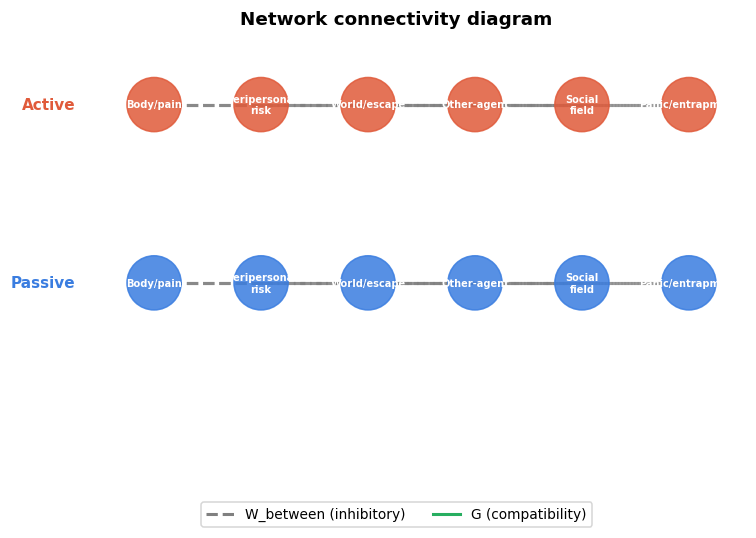

In [9]:
# Preview the network structure before running any simulation
plot_network_diagram(PARAMS["W_between"], PARAMS["G"])


## 7 · Test Simulations

Each simulation uses a fresh copy of the default parameter dict and a clearly
labelled bias setup so they are easy to modify independently.

### Helper: make_params

A small convenience function to clone the default parameter dict and optionally
set a bias matrix `b` in one call.

In [10]:
import copy

def make_params(b: np.ndarray | None = None, **overrides) -> dict:
    """Clone default_params and optionally override fields.

    Parameters
    ----------
    b         : (2, N) bias matrix; if None, uses zeros
    **overrides : any key from default_params() to override

    Returns
    -------
    params dict with W_between and G already built
    """
    p = default_params(N)
    p["W_between"] = build_W_between(N)
    p["G"]         = build_G(N)
    if b is not None:
        p["b"] = b.copy()
    for key, val in overrides.items():
        p[key] = val
    return p


def zero_bias() -> np.ndarray:
    """Return a (2, N) all-zero bias matrix."""
    return np.zeros((2, N))


def bias_at(row: int, col: int, value: float,
            base: np.ndarray | None = None) -> np.ndarray:
    """Return a bias matrix with one entry set, others from base (or zero)."""
    b = zero_bias() if base is None else base.copy()
    b[row, col] = value
    return b


print("Simulation helpers ready.")

Simulation helpers ready.


### Simulation A — Spontaneous attractor settling

No external drive (`b = 0`).  Small random initial conditions.
Does the network settle into a structured pattern, or does activity collapse to zero?

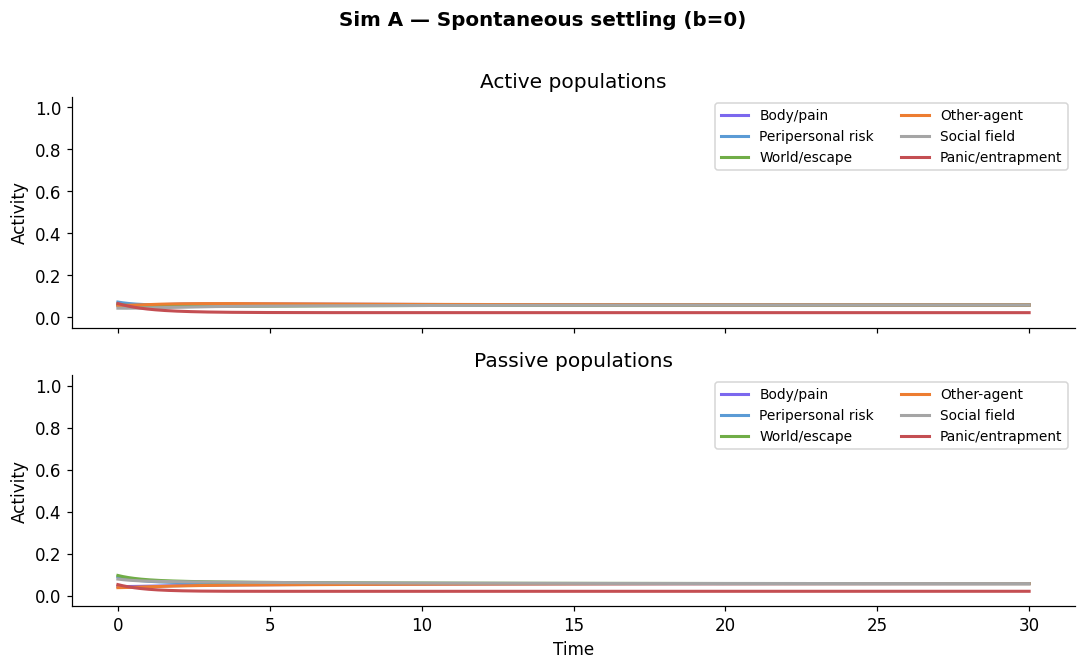

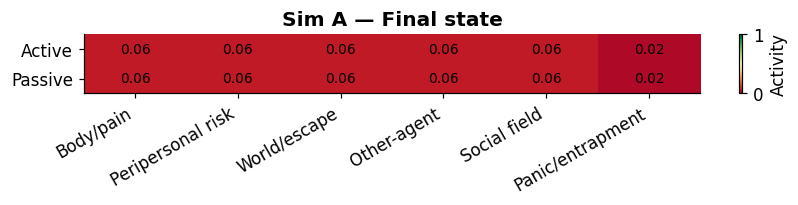

In [11]:
np.random.seed(0)
params_A = make_params()   # b = zero by default

# Small random initial conditions (slight perturbation from 0)
x0_A = np.random.rand(2, N) * 0.1

t_A, traj_A = simulate(x0_A, params_A)

plot_activity_timeseries(t_A, traj_A, title="Sim A — Spontaneous settling (b=0)")
plot_final_state_heatmap(traj_A[-1], title="Sim A — Final state")


### Simulation B — Body/pain passive attractor

High drive to `Passive Body/pain`.
Expect the passive body/pain population to dominate, possibly activating
`Active World/escape` via the compatibility link (analgesia ↔ escape).

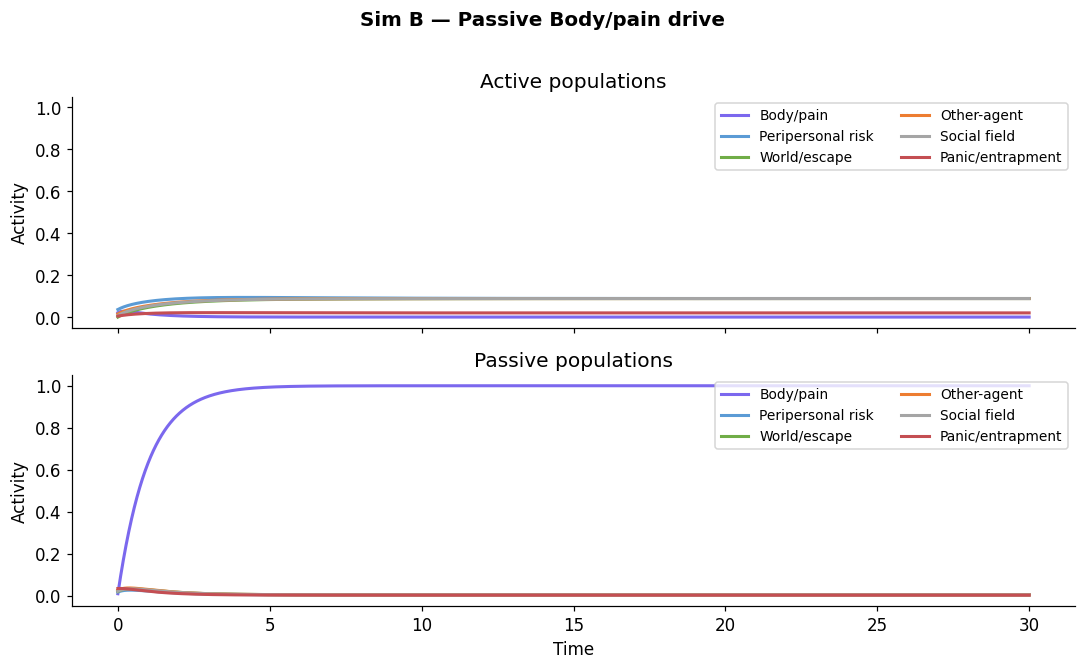

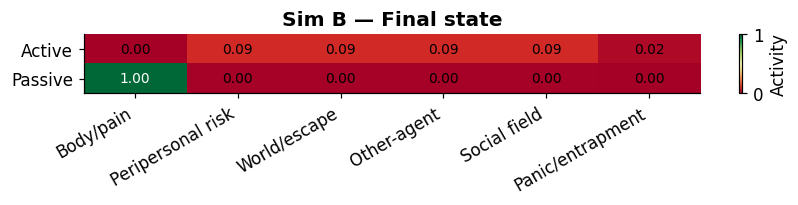

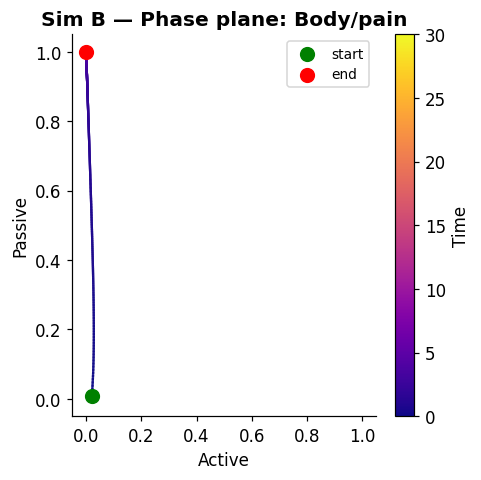

In [12]:
np.random.seed(1)

b_B = bias_at(ROW_PASSIVE, COL_BODY, value=1.5)
params_B = make_params(b=b_B)
x0_B = np.random.rand(2, N) * 0.05

t_B, traj_B = simulate(x0_B, params_B)

plot_activity_timeseries(t_B, traj_B, title="Sim B — Passive Body/pain drive")
plot_final_state_heatmap(traj_B[-1], title="Sim B — Final state")
plot_phase_plane_for_column(t_B, traj_B, COL_BODY,
                            title="Sim B — Phase plane: Body/pain")


### Simulation C — Flight + analgesia coalition

High drive to `Active World/escape`, moderate to `Passive Body/pain`.
Compatibility links should cause these two to co-activate.

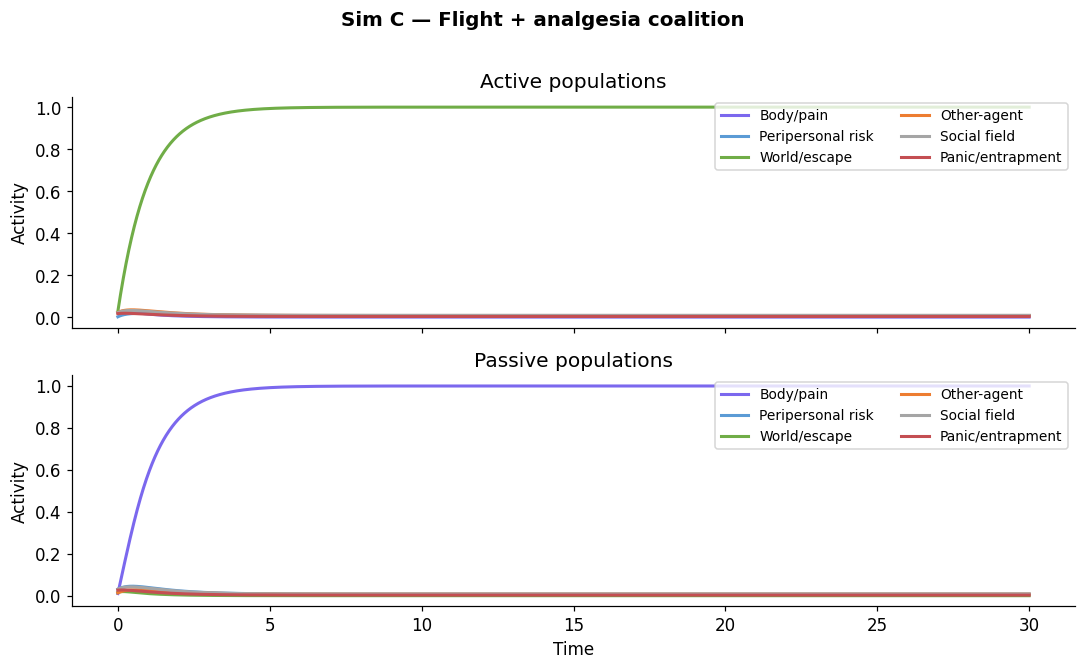

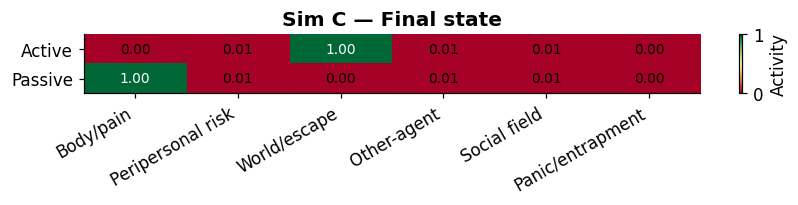

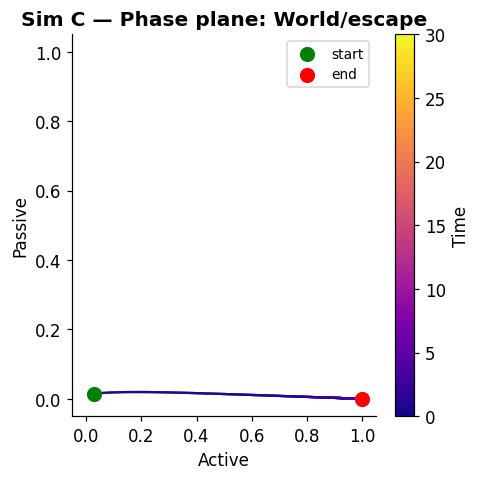

In [13]:
np.random.seed(2)

b_C = zero_bias()
b_C[ROW_ACTIVE,  COL_WORLD] = 1.5   # strong escape drive
b_C[ROW_PASSIVE, COL_BODY]  = 0.8   # moderate pain / analgesia drive

params_C = make_params(b=b_C)
x0_C = np.random.rand(2, N) * 0.05

t_C, traj_C = simulate(x0_C, params_C)

plot_activity_timeseries(t_C, traj_C, title="Sim C — Flight + analgesia coalition")
plot_final_state_heatmap(traj_C[-1], title="Sim C — Final state")
plot_phase_plane_for_column(t_C, traj_C, COL_WORLD,
                            title="Sim C — Phase plane: World/escape")


### Simulation D — Orienting + freezing coalition

High drive to `Active Peripersonal risk`, moderate to `Passive World/escape`.
Expect vigilant orienting paired with passive freeze/hide.

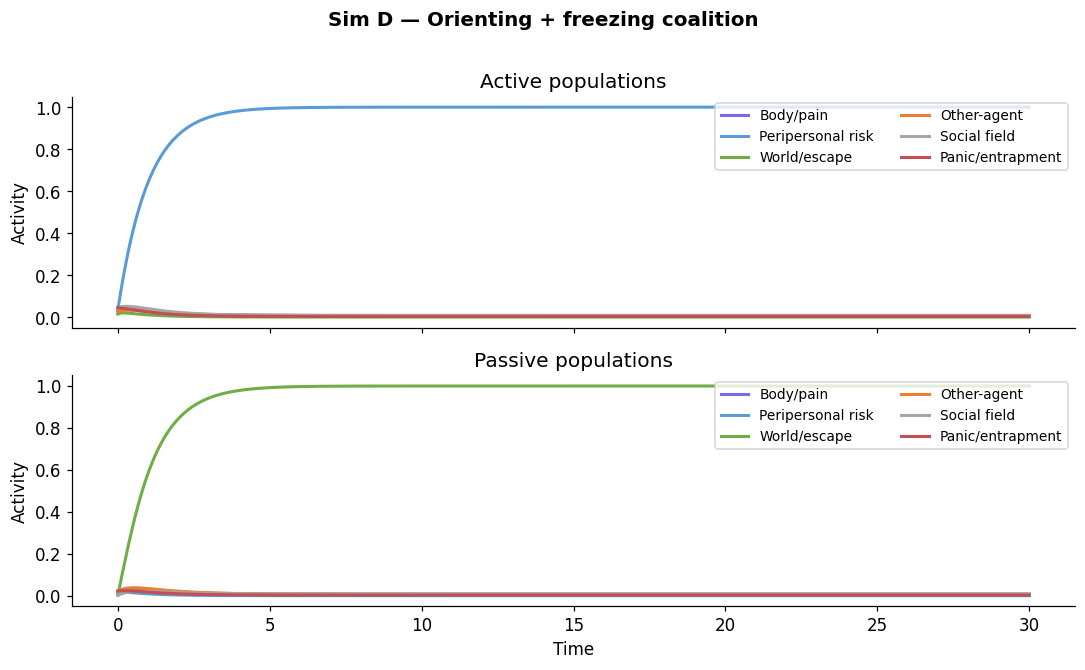

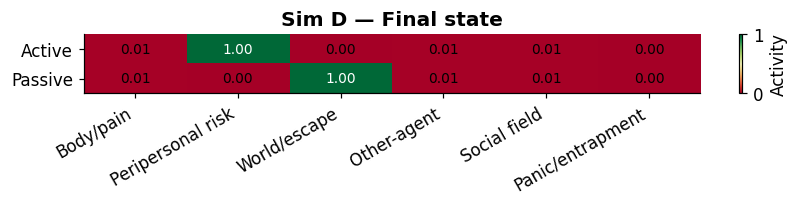

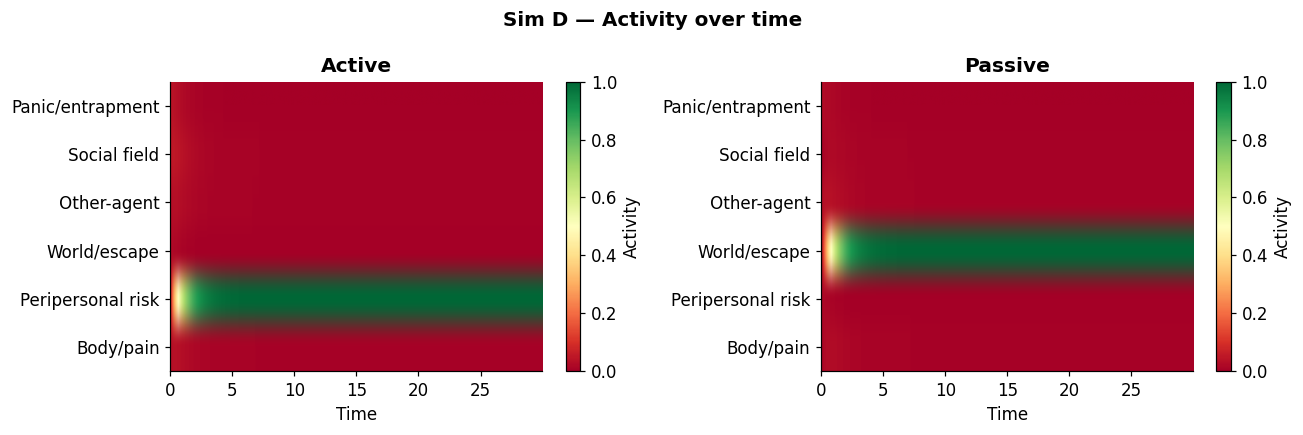

In [14]:
np.random.seed(3)

b_D = zero_bias()
b_D[ROW_ACTIVE,  COL_PERI]  = 1.5   # strong orienting drive
b_D[ROW_PASSIVE, COL_WORLD] = 0.8   # moderate freeze/hide drive

params_D = make_params(b=b_D)
x0_D = np.random.rand(2, N) * 0.05

t_D, traj_D = simulate(x0_D, params_D)

plot_activity_timeseries(t_D, traj_D, title="Sim D — Orienting + freezing coalition")
plot_final_state_heatmap(traj_D[-1], title="Sim D — Final state")
plot_state_heatmap_over_time(t_D, traj_D, title="Sim D — Activity over time")


### Simulation E — Social submission / inhibition coalition

High drives to both `Passive Other-agent` and `Passive Social field`.
Compatibility links should reinforce both passive social states simultaneously.

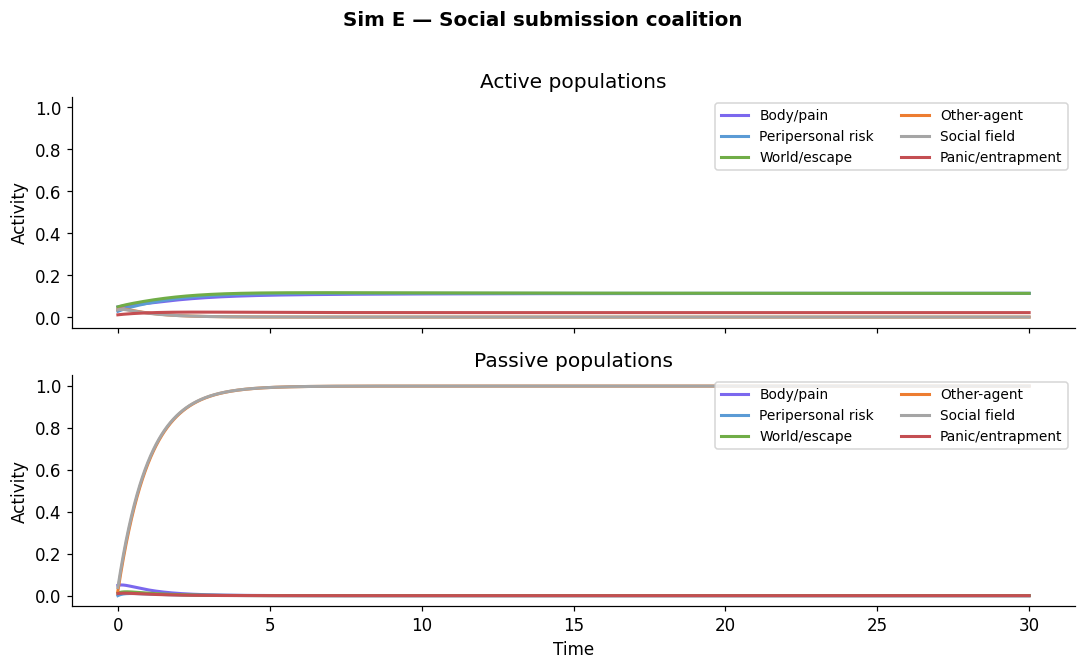

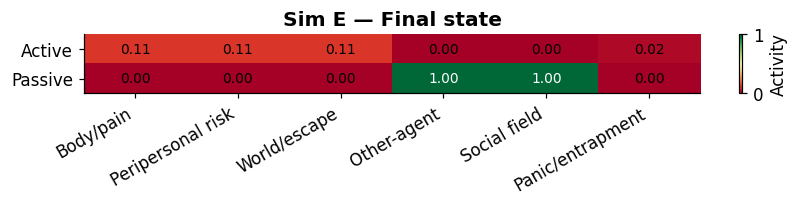

In [15]:
np.random.seed(4)

b_E = zero_bias()
b_E[ROW_PASSIVE, COL_OTHER]  = 1.4
b_E[ROW_PASSIVE, COL_SOCIAL] = 1.4

params_E = make_params(b=b_E)
x0_E = np.random.rand(2, N) * 0.05

t_E, traj_E = simulate(x0_E, params_E)

plot_activity_timeseries(t_E, traj_E, title="Sim E — Social submission coalition")
plot_final_state_heatmap(traj_E[-1], title="Sim E — Final state")


### Simulation F — Active confrontation + vocalisation coalition

High drives to `Active Other-agent` and `Active Social field`.
Expect aggressive confrontation and vocalisation to co-activate and mutually reinforce.

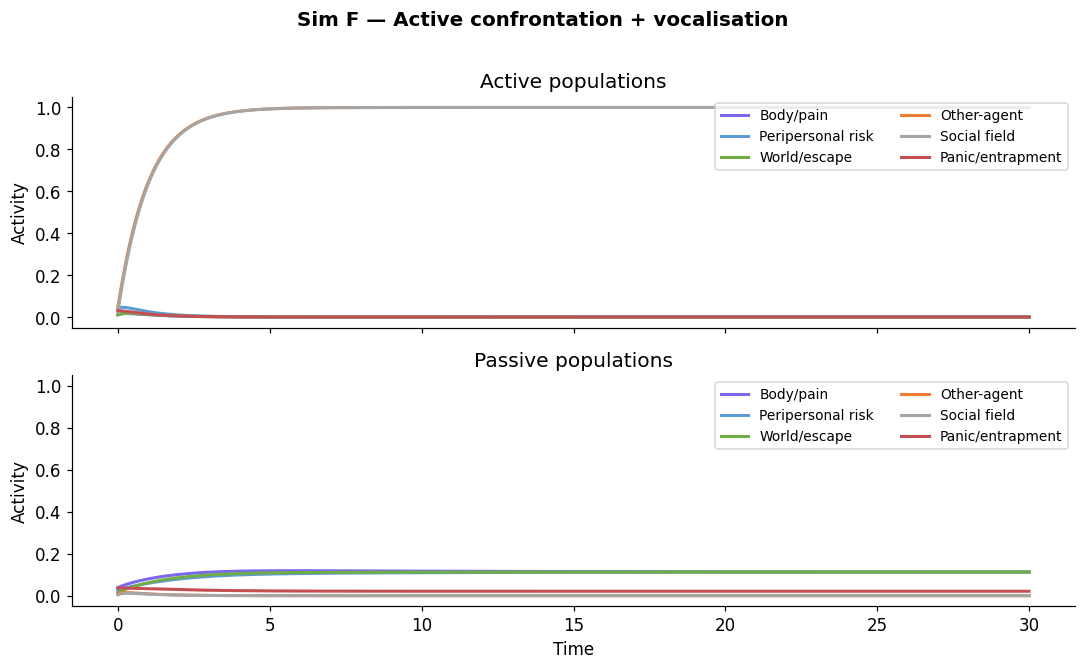

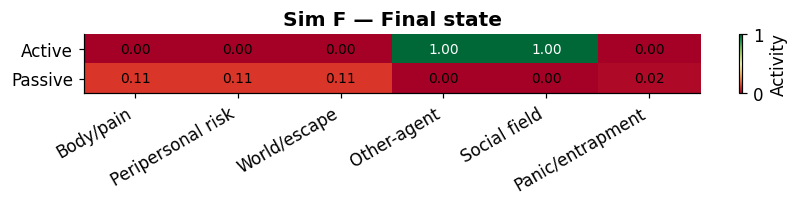

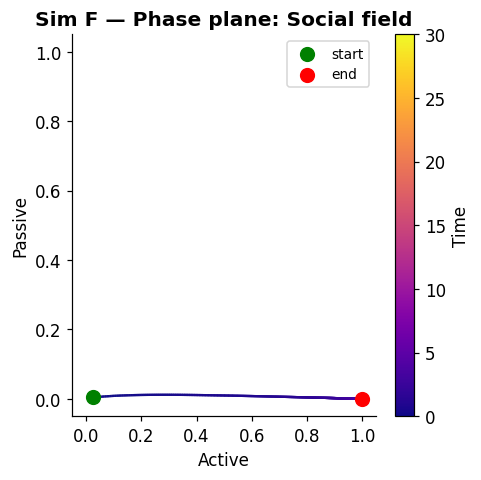

In [16]:
np.random.seed(5)

b_F = zero_bias()
b_F[ROW_ACTIVE,  COL_OTHER]  = 1.4
b_F[ROW_ACTIVE,  COL_SOCIAL] = 1.4

params_F = make_params(b=b_F)
x0_F = np.random.rand(2, N) * 0.05

t_F, traj_F = simulate(x0_F, params_F)

plot_activity_timeseries(t_F, traj_F, title="Sim F — Active confrontation + vocalisation")
plot_final_state_heatmap(traj_F[-1], title="Sim F — Final state")
plot_phase_plane_for_column(t_F, traj_F, COL_SOCIAL,
                            title="Sim F — Phase plane: Social field")


### Simulation F2 — Active panic + escape escalation

High drive to `Active Panic/entrapment`.
Expect frantic escape behaviour, with the compatibility link recruiting
`Active World/escape` (panic → flight escalation).
This tests the new 6th column and its coalitional structure.

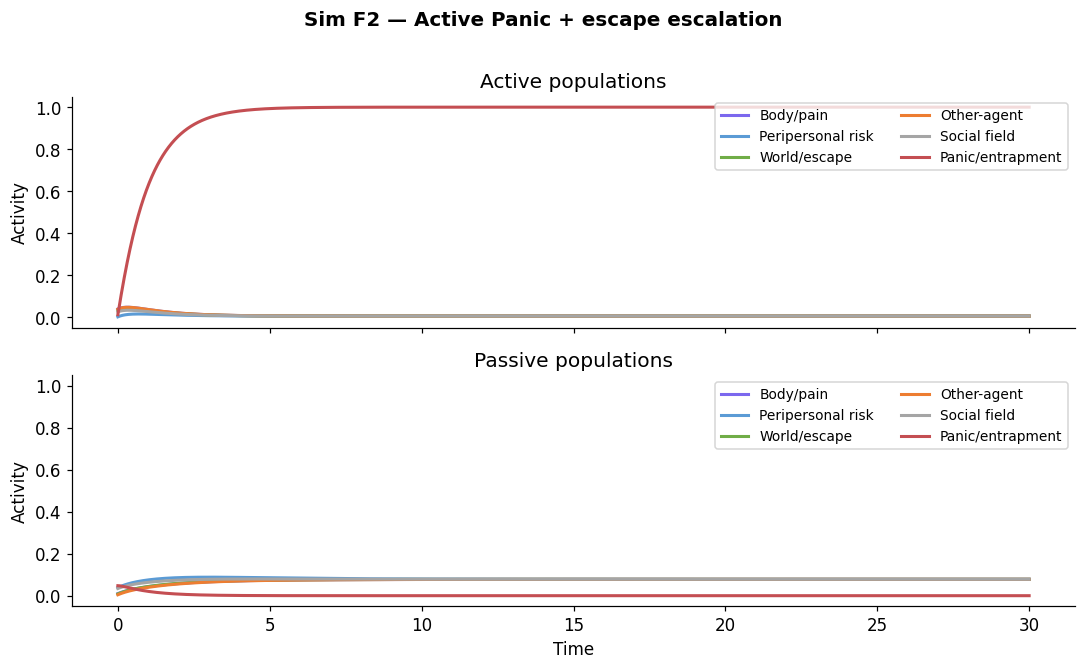

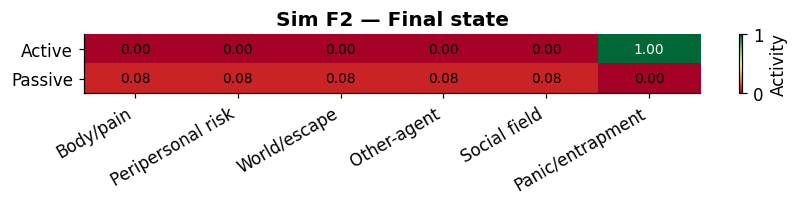

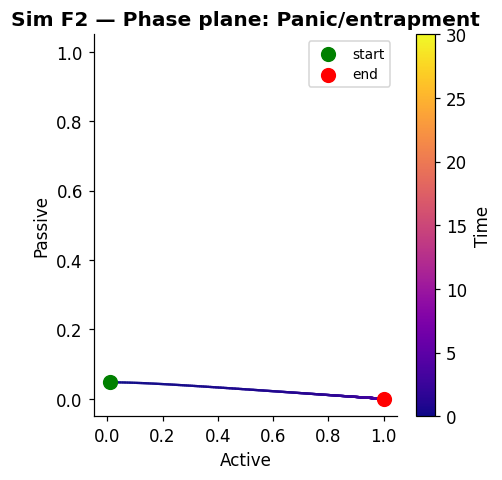

In [17]:
np.random.seed(10)

b_F2 = zero_bias()
b_F2[ROW_ACTIVE, COL_PANIC] = 1.5   # strong panic drive

params_F2 = make_params(b=b_F2)
x0_F2 = np.random.rand(2, N) * 0.05

t_F2, traj_F2 = simulate(x0_F2, params_F2)

plot_activity_timeseries(t_F2, traj_F2, title="Sim F2 — Active Panic + escape escalation")
plot_final_state_heatmap(traj_F2[-1], title="Sim F2 — Final state")
plot_phase_plane_for_column(t_F2, traj_F2, COL_PANIC,
                            title="Sim F2 — Phase plane: Panic/entrapment")

### Simulation F3 — Passive panic / tonic immobility

High drive to `Passive Panic/entrapment`.
Expect shutdown / tonic immobility, with the compatibility link recruiting
`Passive Body/pain` (shutdown → analgesia coalition).
This tests the passive side of the 6th column.

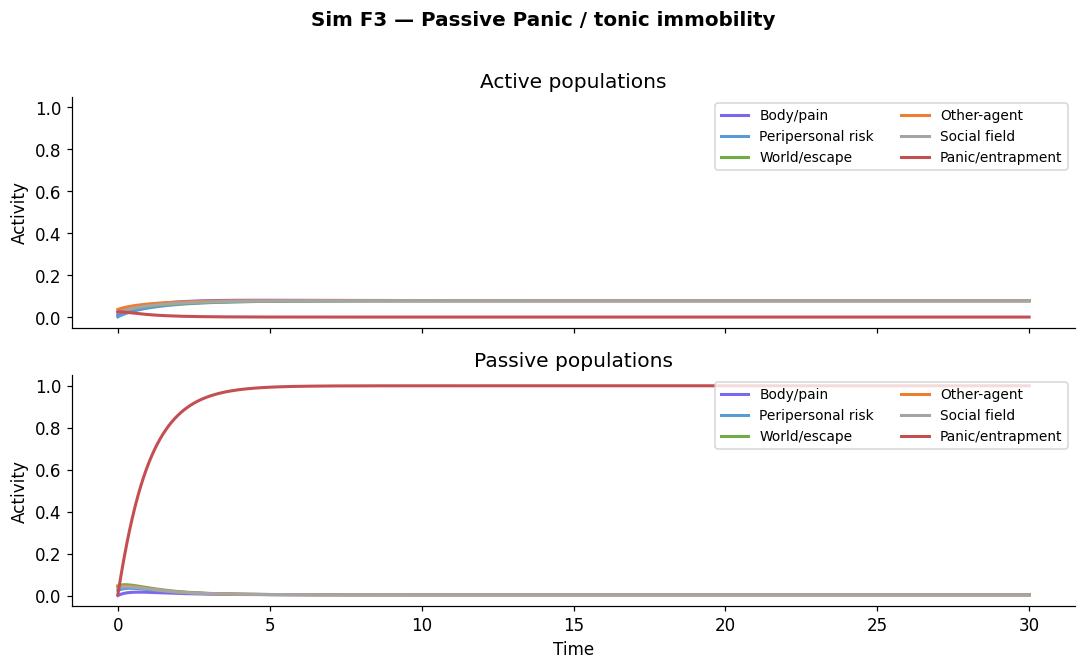

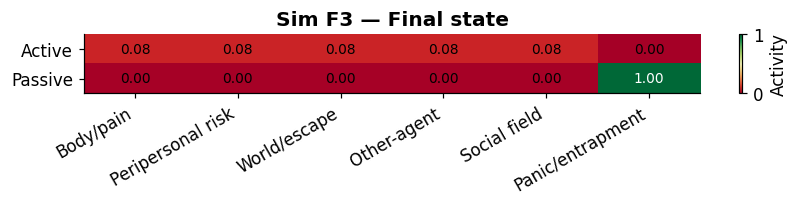

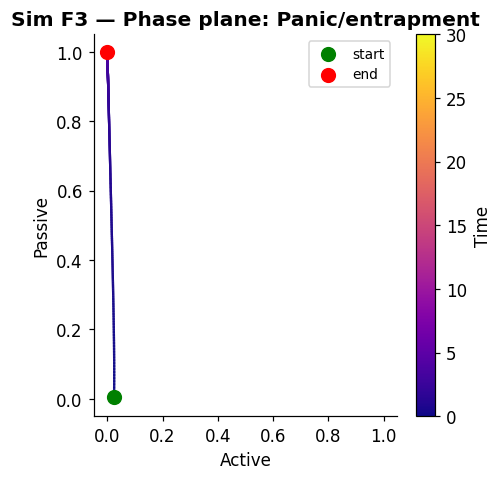

In [18]:
np.random.seed(11)

b_F3 = zero_bias()
b_F3[ROW_PASSIVE, COL_PANIC] = 1.5   # strong shutdown / tonic immobility drive

params_F3 = make_params(b=b_F3)
x0_F3 = np.random.rand(2, N) * 0.05

t_F3, traj_F3 = simulate(x0_F3, params_F3)

plot_activity_timeseries(t_F3, traj_F3, title="Sim F3 — Passive Panic / tonic immobility")
plot_final_state_heatmap(traj_F3[-1], title="Sim F3 — Final state")
plot_phase_plane_for_column(t_F3, traj_F3, COL_PANIC,
                            title="Sim F3 — Phase plane: Panic/entrapment")

### Simulation G — Active / passive switch in the same column

Time-varying `bias_schedule`:
- **First half** (t < T/2): drive `Passive World/escape` → freeze/hide state
- **Second half** (t ≥ T/2): switch drive to `Active World/escape` → flight/escape state

This tests whether the attractor can switch cleanly between modes when the
external drive changes — the core mechanism AIF will later exploit.

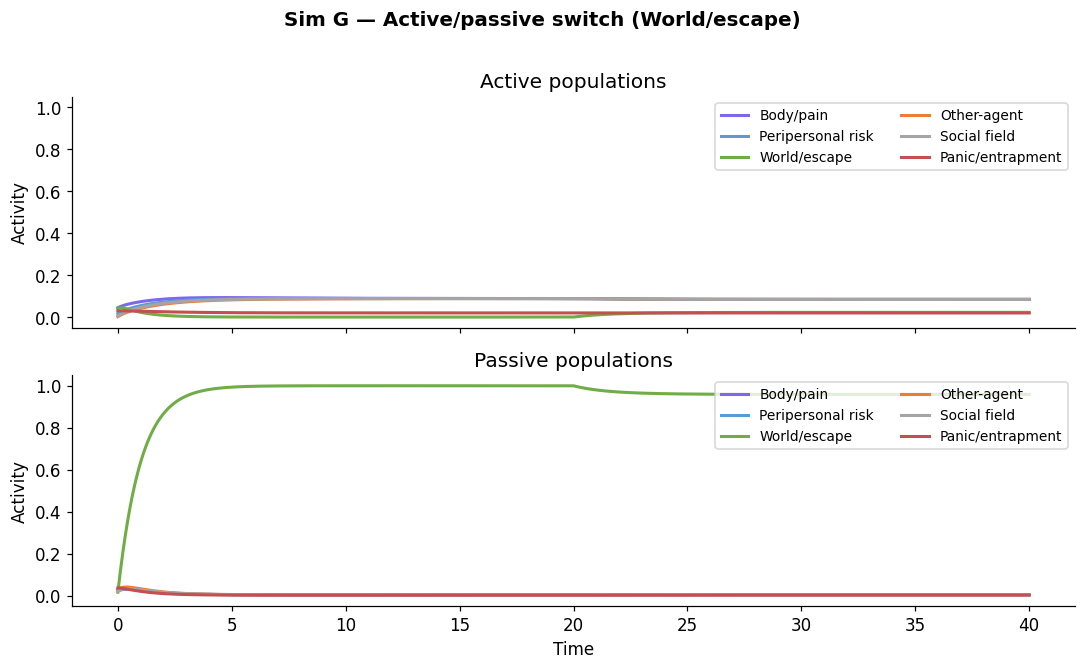

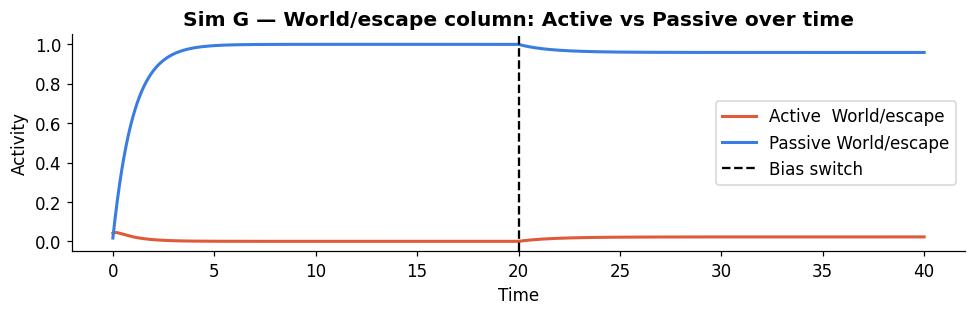

In [19]:
np.random.seed(6)

T_G = 40.0   # longer horizon so both phases are visible

params_G = make_params()  # b in params is irrelevant — overridden by schedule

def bias_schedule_G(t: float) -> np.ndarray:
    """Return bias matrix for time t.

    Phase 1 (t < T/2) : Passive World/escape = 1.5
    Phase 2 (t >= T/2): Active  World/escape = 1.5
    """
    b = zero_bias()
    if t < T_G / 2:
        b[ROW_PASSIVE, COL_WORLD] = 1.5   # freeze / hide
    else:
        b[ROW_ACTIVE,  COL_WORLD] = 1.5   # flight / escape
    return b

x0_G = np.random.rand(2, N) * 0.05
t_G, traj_G = simulate(x0_G, params_G, T=T_G, bias_schedule=bias_schedule_G)

plot_activity_timeseries(t_G, traj_G, title="Sim G — Active/passive switch (World/escape)")

# Highlight the switch time
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_G, traj_G[:, ROW_ACTIVE,  COL_WORLD], lw=2,
        color=_ROW_COLORS[ROW_ACTIVE],  label="Active  World/escape")
ax.plot(t_G, traj_G[:, ROW_PASSIVE, COL_WORLD], lw=2,
        color=_ROW_COLORS[ROW_PASSIVE], label="Passive World/escape")
ax.axvline(T_G / 2, color="k", linestyle="--", lw=1.5, label="Bias switch")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Time")
ax.set_ylabel("Activity")
ax.set_title("Sim G — World/escape column: Active vs Passive over time", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### Simulation H — Parameter sweep: γ × λ_between

Sweep `gamma` (within-column competition) and `lambda_between` (between-column inhibition)
over small ranges.  For each pair run Sim C initial conditions and record a
**dominance score** = mean Active activity − mean Passive activity at the final state.

A large positive value means active mobilisation dominates;
negative means passive/modulatory dominates;
near-zero means mixed or balanced.

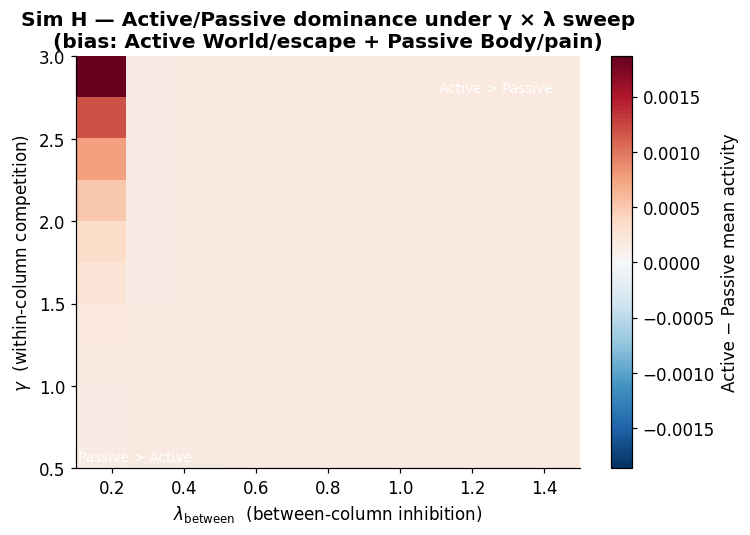

Dominance range: [0.000, 0.002]


In [20]:
np.random.seed(7)

# ── Sweep grid ───────────────────────────────────────────────────────────────
gamma_values  = np.linspace(0.5, 3.0, 10)   # within-column competition
lambda_values = np.linspace(0.1, 1.5, 10)   # between-column inhibition

# Fixed bias (flight + analgesia, same as Sim C)
b_H = zero_bias()
b_H[ROW_ACTIVE,  COL_WORLD] = 1.5
b_H[ROW_PASSIVE, COL_BODY]  = 0.8

# Use a fixed initial condition (small random seed)
x0_H = np.random.rand(2, N) * 0.05

dominance = np.zeros((len(gamma_values), len(lambda_values)))

for gi, g_val in enumerate(gamma_values):
    for li, l_val in enumerate(lambda_values):
        p = make_params(
            b=b_H,
            gamma=np.full(N, g_val),
            lambda_between=l_val,
        )
        _, traj_h = simulate(x0_H, p, T=20.0)
        x_final = traj_h[-1]   # (2, N)
        # Dominance score: mean(active) - mean(passive)
        dominance[gi, li] = x_final[ROW_ACTIVE].mean() - x_final[ROW_PASSIVE].mean()

# ── Plot heatmap ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
vmax = max(abs(dominance.max()), abs(dominance.min()))
im = ax.imshow(
    dominance,
    origin="lower",
    aspect="auto",
    extent=[lambda_values[0], lambda_values[-1],
            gamma_values[0],  gamma_values[-1]],
    vmin=-vmax, vmax=vmax,
    cmap="RdBu_r",
)
plt.colorbar(im, ax=ax, label="Active − Passive mean activity")
ax.set_xlabel(r"$\lambda_{\mathrm{between}}$  (between-column inhibition)")
ax.set_ylabel(r"$\gamma$  (within-column competition)")
ax.set_title(
    "Sim H — Active/Passive dominance under γ × λ sweep\n"
    "(bias: Active World/escape + Passive Body/pain)",
    fontweight="bold",
)

# Contour at dominance = 0 (balance line)
ax.contour(
    lambda_values, gamma_values, dominance,
    levels=[0.0], colors="white", linewidths=1.5, linestyles="--"
)
ax.text(lambda_values[-1] * 0.95, gamma_values[-1] * 0.95,
        "Active > Passive", color="white", ha="right", va="top", fontsize=9)
ax.text(lambda_values[0] * 1.05, gamma_values[0] * 1.05,
        "Passive > Active", color="white", ha="left", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Dominance range: [{dominance.min():.3f}, {dominance.max():.3f}]")


## 8 · Attractor Analysis Utilities

Helper functions for characterising what attractors the network finds,
how robust they are to initial conditions, and where the basin boundaries lie.

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# classify_final_state
# ─────────────────────────────────────────────────────────────────────────────

def classify_final_state(
    x_final: np.ndarray,
    threshold: float = 0.5,
    col_labels: dict = COL_LABELS,
    row_labels: dict = ROW_LABELS,
) -> dict:
    """Return a human-readable dict of which populations are 'on' (> threshold).

    Parameters
    ----------
    x_final   : (2, N) final state array
    threshold : activity threshold for 'active' classification

    Returns
    -------
    dict with keys:
        'on'       : list of (row_name, col_name) tuples above threshold
        'dominant' : 'Active', 'Passive', or 'Balanced'
        'n_active_row' : count of Active row states above threshold
        'n_passive_row': count of Passive row states above threshold
    """
    on = []
    for r in range(x_final.shape[0]):
        for i in range(x_final.shape[1]):
            if x_final[r, i] > threshold:
                on.append((row_labels.get(r, str(r)), col_labels.get(i, str(i))))

    n_act = sum(1 for (r, _) in on if r == row_labels[ROW_ACTIVE])
    n_pas = sum(1 for (r, _) in on if r == row_labels[ROW_PASSIVE])

    if n_act > n_pas:
        dominant = "Active"
    elif n_pas > n_act:
        dominant = "Passive"
    else:
        dominant = "Balanced"

    return {
        "on":            on,
        "dominant":      dominant,
        "n_active_row":  n_act,
        "n_passive_row": n_pas,
    }


# ─────────────────────────────────────────────────────────────────────────────
# compute_row_balance
# ─────────────────────────────────────────────────────────────────────────────

def compute_row_balance(x: np.ndarray) -> float:
    """Active mean − Passive mean across all columns.

    Positive → Active dominates; negative → Passive dominates.
    """
    return float(x[ROW_ACTIVE].mean() - x[ROW_PASSIVE].mean())


# ─────────────────────────────────────────────────────────────────────────────
# compute_column_entropy
# ─────────────────────────────────────────────────────────────────────────────

def compute_column_entropy(x: np.ndarray, eps: float = 1e-8) -> float:
    """Shannon entropy over the 2*N activity values (normalised to sum to 1).

    High entropy → activity spread across many populations.
    Low entropy  → activity concentrated (clear attractor coalition).
    """
    flat = x.flatten()
    flat = np.clip(flat, eps, None)         # avoid log(0)
    flat = flat / flat.sum()                # normalise to probability
    return float(-np.sum(flat * np.log(flat)))


# ─────────────────────────────────────────────────────────────────────────────
# run_multiple_initial_conditions
# ─────────────────────────────────────────────────────────────────────────────

def run_multiple_initial_conditions(
    params: dict,
    n_runs: int = 50,
    T: float = 30.0,
    ic_scale: float = 1.0,
    seed: int = 42,
) -> tuple[np.ndarray, list[dict]]:
    """Run the network from n_runs random initial conditions.

    Parameters
    ----------
    params   : parameter dict
    n_runs   : number of random starts
    T        : simulation horizon
    ic_scale : scale of random initial conditions (uniform in [0, ic_scale])
    seed     : random seed for reproducibility

    Returns
    -------
    finals   : (n_runs, 2, N) array of final states
    labels   : list of classify_final_state dicts
    """
    rng    = np.random.default_rng(seed)
    finals = np.empty((n_runs, 2, params["N"]))
    labels = []

    for run in range(n_runs):
        x0 = rng.uniform(0, ic_scale, size=(2, params["N"]))
        _, traj = simulate(x0, params, T=T)
        x_f = traj[-1]
        finals[run] = x_f
        labels.append(classify_final_state(x_f))

    return finals, labels


print("Attractor analysis utilities defined.")


Attractor analysis utilities defined.


### Attractor basin exploration

Run 50 random initial conditions under the Sim C bias (flight + analgesia).
Visualise the spread of final states and label each run by its dominant row.

Dominant row across 50 runs:
  Active    :   0  (0%)
  Passive   :   0  (0%)
  Balanced  :  50  (100%)


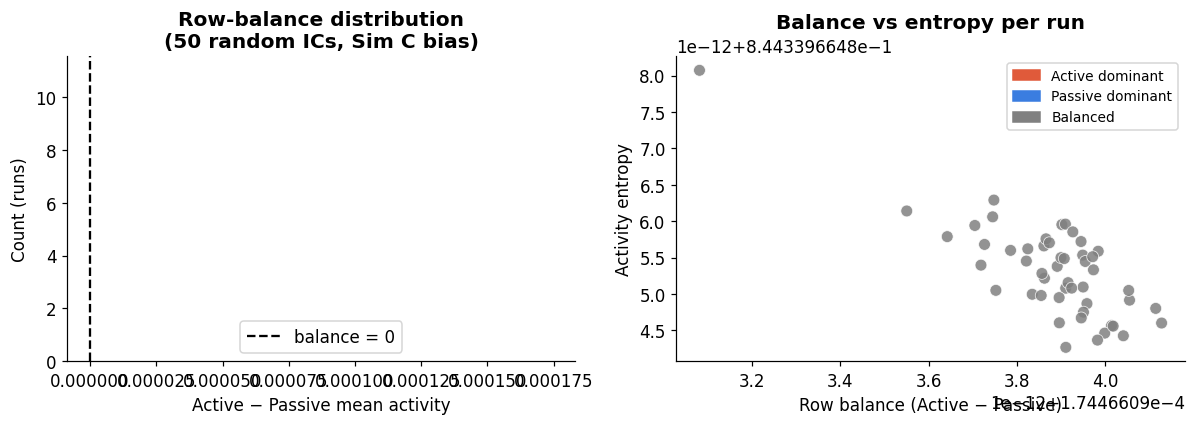

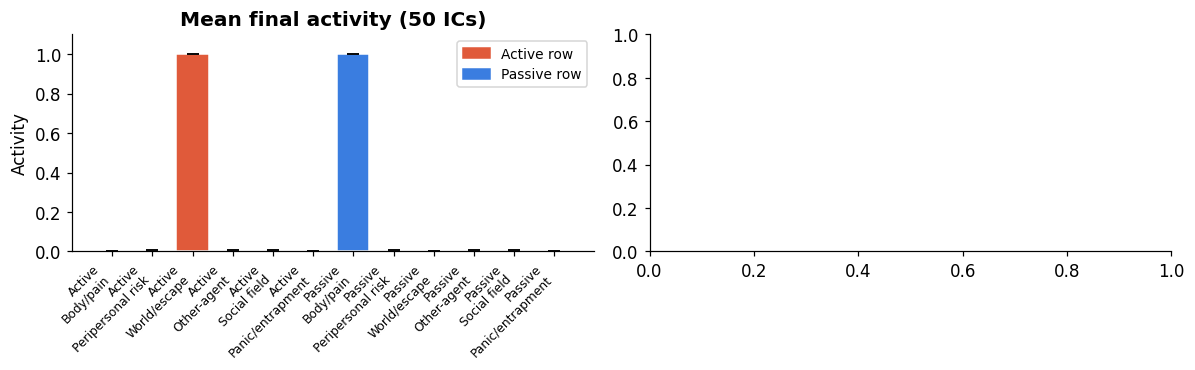

In [22]:
N_RUNS = 50

# Use Sim C parameters (flight + analgesia bias)
b_basin = zero_bias()
b_basin[ROW_ACTIVE,  COL_WORLD] = 1.5
b_basin[ROW_PASSIVE, COL_BODY]  = 0.8
params_basin = make_params(b=b_basin)

finals_basin, labels_basin = run_multiple_initial_conditions(
    params_basin, n_runs=N_RUNS, T=30.0, ic_scale=1.0
)

# ── Summary statistics ────────────────────────────────────────────────────────
balances   = [compute_row_balance(finals_basin[i]) for i in range(N_RUNS)]
entropies  = [compute_column_entropy(finals_basin[i]) for i in range(N_RUNS)]
dominants  = [l["dominant"] for l in labels_basin]
dom_counts = {d: dominants.count(d) for d in ["Active", "Passive", "Balanced"]}

print("Dominant row across 50 runs:")
for k, v in dom_counts.items():
    print(f"  {k:10s}: {v:3d}  ({100*v/N_RUNS:.0f}%)")

# ── Plot 1: Distribution of row-balance scores ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(balances, bins=20, color="#4a90d9", edgecolor="white")
axes[0].axvline(0, color="k", linestyle="--", lw=1.5, label="balance = 0")
axes[0].set_xlabel("Active − Passive mean activity")
axes[0].set_ylabel("Count (runs)")
axes[0].set_title("Row-balance distribution\n(50 random ICs, Sim C bias)", fontweight="bold")
axes[0].legend()

axes[1].scatter(balances, entropies,
                c=[_ROW_COLORS[ROW_ACTIVE] if d == "Active"
                   else _ROW_COLORS[ROW_PASSIVE] if d == "Passive"
                   else "grey"
                   for d in dominants],
                s=60, edgecolors="white", lw=0.5, alpha=0.85)
axes[1].set_xlabel("Row balance (Active − Passive)")
axes[1].set_ylabel("Activity entropy")
axes[1].set_title("Balance vs entropy per run", fontweight="bold")
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color=_ROW_COLORS[ROW_ACTIVE],  label="Active dominant"),
    Patch(color=_ROW_COLORS[ROW_PASSIVE], label="Passive dominant"),
    Patch(color="grey",                   label="Balanced"),
], fontsize=9)

plt.tight_layout()
plt.show()

# ── Plot 2: Mean ± SD of each population across runs ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
pop_labels = [f"{ROW_LABELS[r]}\n{COL_LABELS[i]}"
              for r in range(2) for i in range(N)]
means = finals_basin.reshape(N_RUNS, -1).mean(axis=0)
stds  = finals_basin.reshape(N_RUNS, -1).std(axis=0)
colors_pop = [_ROW_COLORS[r] for r in range(2) for _ in range(N)]

for ax, (m, s, title) in zip(axes, [
    (means, stds, "Mean final activity (50 ICs)"),
]):
    ax.bar(range(len(m)), m, yerr=s, color=colors_pop, edgecolor="white",
           capsize=4, error_kw={"elinewidth": 1.2})
    ax.set_xticks(range(len(m)))
    ax.set_xticklabels(pop_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Activity")
    ax.set_title(title, fontweight="bold")
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color=_ROW_COLORS[ROW_ACTIVE],  label="Active row"),
        Patch(color=_ROW_COLORS[ROW_PASSIVE], label="Passive row"),
    ], fontsize=9)

plt.tight_layout()
plt.show()


### Attractor fingerprints across all simulations

Summarise each named simulation (A–F3) in a single comparison figure:
final-state heatmaps side by side, plus row-balance and entropy bar charts.

C:\Users\mahau\AppData\Local\Temp\ipykernel_22720\3361426870.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


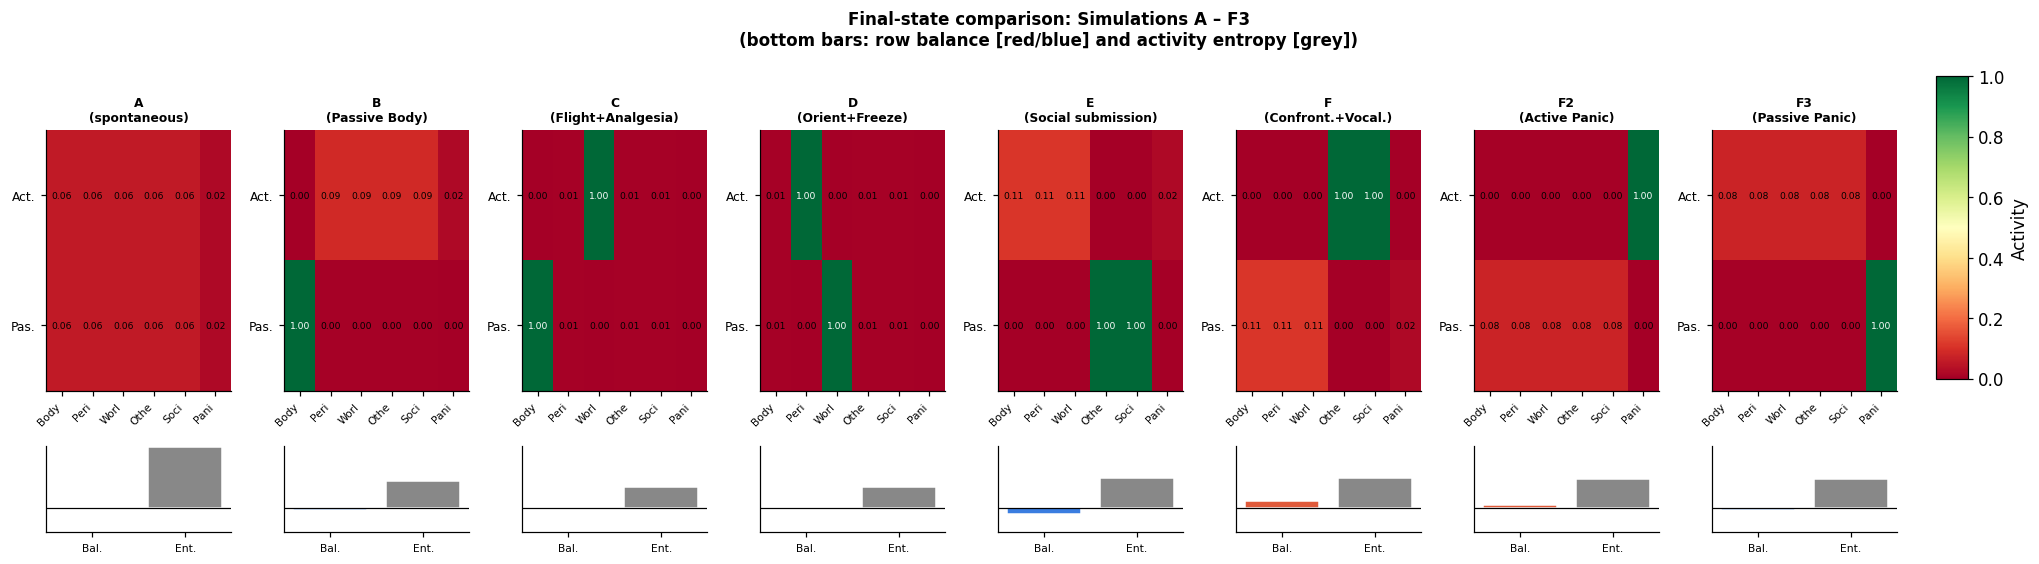


Simulation                     Dominant   Balance   Entropy  Active populations
------------------------------------------------------------------------------------------
A (spontaneous)                Balanced    -0.000     2.442  none
B (Passive Body)                Passive    -0.108     1.081  Passive/Body/pain
C (Flight+Analgesia)           Balanced     0.000     0.844  Active/World/escape, Passive/Body/pain
D (Orient+Freeze)              Balanced     0.000     0.844  Active/Peripersonal risk, Passive/World/escape
E (Social submission)           Passive    -0.273     1.210  Passive/Other-agent, Passive/Social field
F (Confront.+Vocal.)             Active     0.273     1.210  Active/Other-agent, Active/Social field
F2 (Active Panic)                Active     0.105     1.137  Active/Panic/entrapment
F3 (Passive Panic)              Passive    -0.105     1.137  Passive/Panic/entrapment


In [23]:
# Collect final states from simulations A–F3
# (trajectories were computed in Section 7 and are still in scope)
sim_results = {
    "A\n(spontaneous)":             traj_A[-1],
    "B\n(Passive Body)":            traj_B[-1],
    "C\n(Flight+Analgesia)":        traj_C[-1],
    "D\n(Orient+Freeze)":           traj_D[-1],
    "E\n(Social submission)":       traj_E[-1],
    "F\n(Confront.+Vocal.)":        traj_F[-1],
    "F2\n(Active Panic)":           traj_F2[-1],
    "F3\n(Passive Panic)":          traj_F3[-1],
}

sim_names = list(sim_results.keys())
n_sims    = len(sim_names)

# ── Multi-panel heatmap comparison ───────────────────────────────────────────
fig, axes = plt.subplots(2, n_sims, figsize=(n_sims * 2.4, 5),
                         gridspec_kw={"height_ratios": [3, 1]})

for col_idx, (name, x_f) in enumerate(sim_results.items()):
    ax_heat  = axes[0, col_idx]
    ax_stats = axes[1, col_idx]

    # Heatmap
    im = ax_heat.imshow(x_f, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax_heat.set_xticks(range(N))
    ax_heat.set_xticklabels(
        [COL_LABELS[i][:4] for i in range(N)], rotation=45, ha="right", fontsize=7
    )
    ax_heat.set_yticks([0, 1])
    ax_heat.set_yticklabels(["Act.", "Pas."], fontsize=8)
    ax_heat.set_title(name, fontsize=8, fontweight="bold")

    # Annotate cell values
    for r in range(2):
        for i in range(N):
            v = x_f[r, i]
            ax_heat.text(i, r, f"{v:.2f}", ha="center", va="center",
                         fontsize=6, color="white" if v > 0.6 else "black")

    # Stats bar (balance and entropy)
    bal = compute_row_balance(x_f)
    ent = compute_column_entropy(x_f)
    colors_bar = [_ROW_COLORS[ROW_ACTIVE] if bal >= 0 else _ROW_COLORS[ROW_PASSIVE],
                  "#888888"]
    ax_stats.bar(["Bal.", "Ent."],
                 [bal, ent],
                 color=colors_bar,
                 edgecolor="white")
    ax_stats.axhline(0, color="k", lw=0.8)
    ax_stats.set_ylim(-1.0, 2.5)
    ax_stats.tick_params(labelsize=7)
    ax_stats.set_yticks([])

# Shared colour bar
cbar_ax = fig.add_axes([0.92, 0.35, 0.015, 0.55])
fig.colorbar(im, cax=cbar_ax, label="Activity")

fig.suptitle("Final-state comparison: Simulations A – F3\n"
             "(bottom bars: row balance [red/blue] and activity entropy [grey])",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Simulation':<28} {'Dominant':>10} {'Balance':>9} {'Entropy':>9}  Active populations")
print("-" * 90)
for name, x_f in sim_results.items():
    label = classify_final_state(x_f)
    name_clean = name.replace("\n", " ")
    on_str = ", ".join(f"{r}/{c}" for r, c in label["on"]) if label["on"] else "none"
    print(f"{name_clean:<28} {label['dominant']:>10} "
          f"{compute_row_balance(x_f):>9.3f} "
          f"{compute_column_entropy(x_f):>9.3f}  {on_str}")

## 9 · Summary

### What this network implements

This notebook implements a **2 × 6 continuous attractor network** modelling the
defensive policy space of the Periaqueductal Gray (PAG).

| Component | Role |
|---|---|
| **Two rows** (Active / Passive) | Two broad output modes: mobilising vs modulatory |
| **Six columns** | Columns ordered by relational distance to self, from body to panic/entrapment |
| **Self-excitation α** | Each unit can sustain its own activity (attractor property) |
| **Within-column competition γ** | Active and Passive of the same column mutually suppress — only one mode wins per column |
| **Between-column inhibition λ** | Nearby columns compete; favours focal rather than diffuse activity |
| **Compatibility tensor G** | Sparse hand-coded synergy links that allow biologically coherent *coalitions* to form (12 links) |
| **Bias matrix b** | External drive / internal set-point placeholder — the primary AIF interface |

---

### Attractors observed in the simulations

| Simulation | Attractor coalition | Biological interpretation |
|---|---|---|
| A | Low / silent (b = 0) | No drive → no sustained state (below threshold) |
| B | Passive Body/pain dominant | Tonic pain suppression / analgesia |
| C | Active World/escape + Passive Body/pain | Flight with stress analgesia |
| D | Active Peripersonal + Passive World/escape | Vigilant orienting + freezing |
| E | Passive Other-agent + Passive Social field | Submission + low social vocalisation |
| F | Active Other-agent + Active Social field | Confrontation + aggressive vocalisation |
| F2 | Active Panic + Active World/escape | Frantic escape escalation (panic recruits flight) |
| F3 | Passive Panic + Passive Body/pain | Tonic immobility + analgesia/shutdown |
| G | Passive World/escape → Active World/escape | Freeze-to-flight switch on bias change |
| H | Dominance phase boundary in γ–λ space | High γ or low λ expands Active basin |

---

### How Active Inference will enter

The bias placeholder `b[r, i]` and coupling parameters are the natural AIF interface:

| AIF step | PAG network effect |
|---|---|
| Precision-weighted prediction errors update `b` | Shift which coalition is most likely / expected |
| Prior beliefs → modulate `gamma` per column | Change how sharply Active / Passive compete |
| Action-oriented policies → increase `eta` on specific G links | Strengthen task-relevant coalitions |
| Somatosensory prediction errors → feed `b[Passive, Body]` | Drive pain / analgesia states from interoceptive model |
| Higher-level social priors → bias `b[:, Other/Social]` columns | Set approach vs submission expectation |
| Entrapment detection → bias `b[:, Panic]` column | Trigger panic escalation or tonic immobility |

The current network provides the **generative model dynamics**; the AIF layer will provide
the **inference and learning** that selects and stabilises appropriate attractors based on
the agent's beliefs and goals.

## 10 · Diagnostic Findings: 6-Column Attractor Collapse

### Problem statement

After extending the network from 2 × 5 to 2 × 6 (adding Panic/entrapment), re-running
all simulations revealed a **loss of discriminative power**. Simulations A, B, C, and F3
converge to the **same final attractor** despite receiving different biases:

| Simulation | Bias | Expected attractor | Actual attractor |
|---|---|---|---|
| A (b=0) | None | Silent / near-zero | Active World + Passive Body + **Passive Panic** |
| B | Passive Body = 1.5 | Passive Body dominant | Same as A |
| C | Active World = 1.5, Passive Body = 0.8 | Flight + analgesia coalition | Same as A |
| F2 | Active Panic = 1.5 | Active Panic + Active World | Active World + Active Panic + Passive Body + Passive Other + Passive Social |
| F3 | Passive Panic = 1.5 | Passive Panic + Passive Body | Same as A |

The network has collapsed into a dominant attractor basin that absorbs most initial
conditions and bias configurations.

### Root cause analysis

**Two interacting failures:**

#### 1. Positive feedback loop in G tensor (neuroscientifically incorrect)

The bidirectional excitatory links Passive Panic ↔ Passive Body create a
**self-reinforcing coalition** with no natural brake. This coalition then recruits
Active World/escape via the pre-existing Passive Body → Active World compatibility link,
forming a three-way runaway attractor.

**The neuroscience contradicts this wiring.** Fear-induced analgesia (Bolles & Fanselow,
1980; Fanselow, 1986) is one of the most robust findings in PAG research: when
fear/panic activates, pain processing is **suppressed** via descending opioid modulation
from vlPAG. The real PAG implements a **negative feedback cascade**:

```
Pain → Escape → (failed escape) → Panic → Analgesia ──┤ Pain
                                                        (inhibits)
```

- **Panic → Body/pain should be INHIBITORY** (fear-induced analgesia)
- **Body/pain → Panic should be ABSENT** at the PAG level (pain drives escape via
  dlPAG, not panic; the path from pain to panic requires higher-level threat appraisal
  through amygdala/vmPFC, not direct PAG column interaction)

#### 2. Edge effect in distance-dependent W_between

With the exponential kernel `W_ij = exp(-|i-j|/σ)` on a linear topology of N=6 columns,
the inhibition between columns 0 (Body) and 5 (Panic) is:

```
W[0,5] = exp(-5/1.5) = 0.036
```

This is effectively zero — Body and Panic are free to co-activate without any lateral
competition. The problem is that the column ordering (relational distance to self) was
**conceptual, not anatomical**. PAG columns are not physically arranged in a line;
they are interleaved in the dorsoventral and rostrocaudal axes. Imposing distance-dependent
inhibition projects a spatial structure that does not exist in the anatomy.

### Why the 5-column network didn't show this

With N=5 (no Panic column), the G tensor had 8 links forming 4 balanced coalitions.
No coalition was connected to more than one other, preventing runaway recruitment chains.
Adding Panic with bidirectional links to Body created a **bridge** between the
Body-World coalition and the new Panic node, and the weak inhibition at W[0,5]=0.036
could not counteract it.

## 11 · Literature-Informed Constraints

### PAG column connectivity: what the anatomy actually says

The foundational tracing studies (Beitz, 1982; Bandler & Shipley, 1994; Keay & Bandler,
2001) and recent optogenetic work (Tovote et al., 2016; Evans et al., 2018) reveal that
PAG intrinsic connectivity follows **functional grouping**, not distance-dependent topology:

**Key architectural principles:**

1. **Active vs passive is the primary competition axis.** vlPAG (passive/modulatory)
   and dlPAG (active/mobilising) have the strongest reciprocal inhibition, mediated by
   GABAergic interneurons. This maps directly to the row structure (gamma parameter).

2. **Active columns cooperate.** dmPAG, dlPAG, and lPAG (corresponding to active rows
   of Body, Peripersonal, World, and Other-agent columns) have mutual excitatory
   connections — they form a cooperative cluster supporting escalating active defense.

3. **Inhibition between columns is NOT distance-dependent.** The columns are interleaved
   anatomically, not arranged in a line. Functional inhibition between columns is closer
   to **uniform global inhibition** with structure provided by compatibility/synergy (G),
   not by spatial proximity.

4. **vlPAG → dlPAG inhibition is stronger and more sustained** than dlPAG → vlPAG.
   This asymmetry (passive suppressing active more than reverse) could be captured by
   asymmetric gamma values, but is not yet implemented.

### Panic/entrapment: activation threshold and temporal dynamics

Microstimulation studies provide quantitative constraints on the Panic column:

- **Panic requires 2-3× the stimulation current** of simple flight/escape responses
  in dlPAG (Schenberg et al., 2001; Johnson et al., 2008). This supports a higher
  activation threshold (theta) for the Panic column.

- **Threat imminence continuum** (Mobbs et al., 2007, 2009, 2010): as threat becomes
  more imminent, PAG processing shifts from vlPAG (freezing, distal threat) → dlPAG
  (flight, proximal threat). At maximum imminence / entrapment, there is a shift
  **back toward vlPAG** (tonic immobility / collapsed defense). This suggests Panic
  is not a separate parallel system but the **far end of a dynamic trajectory** through
  the PAG, requiring sustained failed escape before it engages.

- **Temporal dynamics**: dlPAG (active) responses have fast onset (~20-50ms) but
  require ongoing input. vlPAG (passive) responses are slower to activate (~50-150ms)
  but self-sustaining once engaged. Panic-like responses fall in the dlPAG timing
  range but with higher threshold.

### Fear-induced analgesia: the Panic → Pain inhibitory link

One of the most robust and well-replicated PAG findings (Bolles & Fanselow, 1980;
Fanselow, 1986; Deng, Xiao & Wang, 2016):

- During intense fear/panic, vlPAG-mediated **opioid analgesia is recruited**,
  meaning panic **suppresses pain awareness** via descending modulation
- This is largely **unidirectional**: intense fear/panic → analgesia, but pain does
  NOT reliably trigger panic at the PAG level
- The vlPAG mu-opioid receptor neurons that mediate analgesia receive **inhibitory**
  input from dlPAG, providing a substrate for active states to gate pain processing

### Indirect feedback loops: what the AIF layer should handle

The full Pain → Escape → Panic → Analgesia cascade involves relay stations outside the
PAG (Raphe nucleus, nucleus accumbens, hypothalamus). These indirect loops should be
captured by the **AIF bias computation** (modulating b[r,i] over time based on inference),
not by direct G tensor links within the PAG network. This keeps the G tensor restricted
to anatomically verified PAG-internal connections.

### Center-surround / competitive network theory

The attractor network literature provides principled guidance on the inhibition structure:

- **Amari (1977)**: Neural field stability requires that bump width self-organizes from
  the connectivity kernel. For localized attractors to form, inhibition must be broader
  than excitation (Mexican hat / center-surround).

- **Rutishauser, Douglas & Slotine (2011)**: Winner-take-all stability requires
  `self_excitation > 1` for persistence and `inhibition > self_excitation - 1` for
  competition. The ratio `self_exc / inhibition` controls soft vs hard WTA regime.

- **Carandini & Heeger (2012)**: Divisive normalization (a canonical neural computation)
  prevents any single unit from dominating by bounding responses relative to pool activity.

- **Wang (2002)**: In biophysical decision networks, the ratio of structured excitation
  (within-group) to uniform inhibition (across-group) must satisfy `w+ > 1` but below
  a critical threshold that scales inversely with the number of competing populations.

For a network of N=6 columns where the columns are not spatially ordered, the most
principled inhibition structure is **uniform global inhibition**: every column inhibits
every other column with equal strength, and all spatial structure emerges from the
self-excitation (alpha) and compatibility tensor (G).

## 12 · Proposed Changes (v2 Architecture)

Based on the diagnostic findings and literature review, the following changes are
proposed. The strategy is **incremental**: fix the inhibition topology first, verify
pure competition works, then add G links back one at a time.

### Change 1: Uniform global inhibition (replace W_between)

**Before:** `W_ij = exp(-|i-j|/σ)` — distance-dependent on linear topology

**After:** `W_ij = 1` for all `i ≠ j`, `W_ii = 0` — uniform global inhibition

**Rationale:** PAG columns are not spatially ordered. The conceptual ordering
(relational distance to self) does not correspond to anatomical proximity. All
competitive structure should emerge from the compatibility tensor G, not from
imposed spatial topology. The center-surround emerges from self-excitation (alpha)
as the "center" plus uniform global inhibition (lambda) as the "surround".

**Parameters removed:** `sigma_w`

### Change 2: Strip G tensor (start clean)

**Before:** 12 compatibility links, some neuroscientifically incorrect

**After:** G = 0 (empty tensor). All links disabled.

**Rationale:** Verify that pure competition (alpha + gamma + lambda) produces
well-behaved attractor dynamics with 6 columns before introducing any coalitions.
G links will be reintroduced incrementally in subsequent experiments, each justified
by specific PAG anatomy:

**Planned G link reintroduction order** (each added after verifying the previous):

| Priority | Link | Direction | Weight | Anatomical basis |
|---|---|---|---|---|
| 1 | Active World → Passive Body | Excitatory | +1.0 | Flight activates analgesia (dlPAG → vlPAG opioid) |
| 2 | Passive Body → Active World | Excitatory | +1.0 | Analgesia enables escape (vlPAG disinhibition of dlPAG) |
| 3 | Active Peri → Passive World | Excitatory | +1.0 | Orienting primes freeze (lPAG → vlPAG) |
| 4 | Passive World → Active Peri | Excitatory | +1.0 | Freeze sustains vigilance (vlPAG → lPAG) |
| 5 | Active Other ↔ Active Social | Excitatory | +1.0 | Confrontation + vocalisation (dmPAG coordination) |
| 6 | Passive Other ↔ Passive Social | Excitatory | +1.0 | Submission + low signalling (vlPAG social) |
| 7 | Active Panic → Active World | Weak exc. | +0.3 | Panic recruits flight (within dlPAG, escalation) |
| 8 | Active World → Active Panic | Weak exc. | +0.2 | Failed escape → panic (gated, requires failure signal) |
| 9 | Active Panic → Passive Body | **Inhibitory** | **-0.5** | Fear-induced analgesia (Fanselow, 1986) |

**Links NOT included** (indirect, handled by AIF):

| Link | Reason for exclusion |
|---|---|
| Passive Body → Passive Panic | Pain does not trigger panic at PAG level; requires amygdala/vmPFC appraisal |
| Passive Panic → Passive Body (excitatory) | Replaced by inhibitory Panic → Body link (fear-induced analgesia) |

### Change 3: Per-column activation threshold (theta vector)

**Before:** Scalar `theta = 0.5` for all columns

**After:** `theta = [0.5, 0.5, 0.5, 0.5, 0.5, 0.75]` — Panic has higher threshold

**Rationale:** Microstimulation data (Schenberg et al., 2001; Johnson et al., 2008)
shows panic-like responses require 2-3× the current of flight/escape. Panic should
only engage when other escape strategies fail and drive is very high.

### Change 4: Noise (optional, after deterministic validation)

**Before:** `noise = 0.0` (deterministic)

**After:** `noise ∈ {0.0, 0.02, 0.05}` — test robustness

**Rationale:** Alejandro's suggestion. Small noise can help avoid spurious attractors
and test whether the attractor landscape is robust. Run deterministic first for clean
interpretation, then validate with noise.

### Hypotheses for v2

After implementing changes 1-3 (uniform W, empty G, per-column theta):

| Hypothesis | Test |
|---|---|
| H1: With G=0 and uniform W, bias to a single population should activate only that population (no spurious coalitions) | Run Sims A-F3 with empty G |
| H2: Adding flight-analgesia G links back should recreate the C and D attractor coalitions from v1 | Reintroduce links 1-4, re-run C and D |
| H3: Panic column should only activate under strong direct drive (theta=0.75 prevents spontaneous engagement) | Run F2 and F3 with new theta |
| H4: The inhibitory Panic → Body link should prevent the runaway attractor | Add link 9, verify no spontaneous Panic+Body co-activation |
| H5: Weak Panic-World excitatory links (0.2-0.3) should allow coalitions under strong drive without dominating | Add links 7-8, sweep bias strength |

### References

- Amari, S. (1977). Dynamics of pattern formation in lateral-inhibition type neural fields. *Biological Cybernetics*, 27, 77-87.
- Bandler, R. & Shipley, M. T. (1994). Columnar organization in the midbrain PAG. *Trends in Neurosciences*, 17(9), 379-389.
- Beitz, A. J. (1982). The organization of afferent projections to the midbrain PAG. *Neuroscience*, 7(1), 133-159.
- Bolles, R. C. & Fanselow, M. S. (1980). A perceptual-defensive-recuperative model of fear and pain. *Behavioral and Brain Sciences*, 3(2), 291-301.
- Carandini, M. & Heeger, D. J. (2012). Normalization as a canonical neural computation. *Nature Reviews Neuroscience*, 13(1), 51-62.
- Deng, H., Xiao, X. & Wang, Z. (2016). Periaqueductal gray neuronal activities underlie different aspects of defensive behaviors. *Journal of Neuroscience*, 36(29), 7580-7588.
- Evans, D. A. et al. (2018). A synaptic threshold mechanism for computing escape decisions. *Nature*, 558, 590-594.
- Fanselow, M. S. (1986). Conditioned fear-induced opiate analgesia. In D. D. Kelly (Ed.), *Stress-Induced Analgesia* (pp. 40-54). Annals of the New York Academy of Sciences.
- Johnson, P. L. et al. (2008). Neural pathways underlying lactate-induced panic. *Neuropsychopharmacology*, 33(9), 2093-2107.
- Keay, K. A. & Bandler, R. (2001). Parallel circuits mediating distinct emotional coping reactions to different types of stress. *Neuroscience & Biobehavioral Reviews*, 25(7-8), 669-678.
- Mobbs, D. et al. (2007). When fear is near: threat imminence elicits prefrontal-PAG shifts in humans. *Science*, 317(5841), 1079-1083.
- Mobbs, D. et al. (2009). From threat to fear: the neural organization of defensive fear systems in humans. *Journal of Neuroscience*, 29(39), 12236-12243.
- Mobbs, D. et al. (2010). Neural activity associated with monitoring the oscillating threat value of a tarantula. *PNAS*, 107(47), 20582-20586.
- Rutishauser, U., Douglas, R. J. & Slotine, J.-J. E. (2011). Collective stability of networks of winner-take-all circuits. *Neural Computation*, 23(3), 735-773.
- Schenberg, L. C. et al. (2001). Modeling panic attacks. *Neuroscience & Biobehavioral Reviews*, 25(7-8), 647-659.
- Tovote, P. et al. (2016). Midbrain circuits for defensive behaviour. *Nature*, 534(7606), 206-212.
- Wang, X.-J. (2002). Probabilistic decision making by slow reverberation in cortical circuits. *Neuron*, 36(5), 955-968.

## 13 · Incremental G Link Reintroduction

Following the plan in Section 12, we reintroduce compatibility links one at a time
and verify that each addition preserves (or intentionally extends) the attractor
landscape.

**Protocol:**
1. Start from v2 baseline (G = 0, uniform W, per-column theta)
2. Add each link cumulatively in priority order
3. After each addition, run all 8 standard simulations (A–F3) plus two
   indirect-recruitment tests (C\*, D\*) that omit one member of the expected
   coalition to check whether the G link recruits it
4. Flag any simulation whose active populations changed from the previous step

**Indirect recruitment tests:**
- **C\*** — Only Active World bias (1.5), no Passive Body bias. Tests whether
  link 1 (Act.World → Pas.Body) recruits analgesia without direct drive.
- **D\*** — Only Active Peri bias (1.5), no Passive World bias. Tests whether
  link 3 (Act.Peri → Pas.World) recruits freezing without direct drive.

In [24]:
# ── G-link steps (priority order from Section 12) ────────────────────────────
# Each step adds one or two directed links to G.
# Tuple format: (target_row, target_col, source_row, source_col, weight)
# G[tgt_r, tgt_i, src_r, src_i] = weight

G_LINK_STEPS = [
    {
        "label": "Act.World \u2192 Pas.Body (+1.0, flight\u2192analgesia)",
        "links": [(ROW_PASSIVE, COL_BODY, ROW_ACTIVE, COL_WORLD, 1.0)],
    },
    {
        "label": "Pas.Body \u2192 Act.World (+1.0, analgesia\u2192escape)",
        "links": [(ROW_ACTIVE, COL_WORLD, ROW_PASSIVE, COL_BODY, 1.0)],
    },
    {
        "label": "Act.Peri \u2192 Pas.World (+1.0, orient\u2192freeze)",
        "links": [(ROW_PASSIVE, COL_WORLD, ROW_ACTIVE, COL_PERI, 1.0)],
    },
    {
        "label": "Pas.World \u2192 Act.Peri (+1.0, freeze\u2192vigilance)",
        "links": [(ROW_ACTIVE, COL_PERI, ROW_PASSIVE, COL_WORLD, 1.0)],
    },
    {
        "label": "Act.Other \u2194 Act.Social (+1.0, confront+vocal)",
        "links": [
            (ROW_ACTIVE, COL_SOCIAL, ROW_ACTIVE, COL_OTHER, 1.0),
            (ROW_ACTIVE, COL_OTHER, ROW_ACTIVE, COL_SOCIAL, 1.0),
        ],
    },
    {
        "label": "Pas.Other \u2194 Pas.Social (+1.0, submission+signal)",
        "links": [
            (ROW_PASSIVE, COL_SOCIAL, ROW_PASSIVE, COL_OTHER, 1.0),
            (ROW_PASSIVE, COL_OTHER, ROW_PASSIVE, COL_SOCIAL, 1.0),
        ],
    },
    {
        "label": "Act.Panic \u2192 Act.World (+0.3, panic recruits flight)",
        "links": [(ROW_ACTIVE, COL_WORLD, ROW_ACTIVE, COL_PANIC, 0.3)],
    },
    {
        "label": "Act.World \u2192 Act.Panic (+0.2, failed escape\u2192panic)",
        "links": [(ROW_ACTIVE, COL_PANIC, ROW_ACTIVE, COL_WORLD, 0.2)],
    },
    {
        "label": "Act.Panic \u2192 Pas.Body (-0.5, fear-induced analgesia)",
        "links": [(ROW_PASSIVE, COL_BODY, ROW_ACTIVE, COL_PANIC, -0.5)],
    },
]


def build_G_from_steps(N: int, steps: list) -> np.ndarray:
    """Build G tensor by applying a list of link-step dicts.

    Parameters
    ----------
    N     : number of columns
    steps : list of dicts, each with a 'links' key containing
            (tgt_r, tgt_i, src_r, src_i, weight) tuples

    Returns
    -------
    G : (2, N, 2, N) ndarray
    """
    G = np.zeros((2, N, 2, N), dtype=float)
    for step in steps:
        for (tgt_r, tgt_i, src_r, src_i, w) in step["links"]:
            G[tgt_r, tgt_i, src_r, src_i] = w
    return G


# ── Simulation configurations (name, bias, seed) ─────────────────────────────

b_C_inc = zero_bias()
b_C_inc[ROW_ACTIVE,  COL_WORLD] = 1.5
b_C_inc[ROW_PASSIVE, COL_BODY]  = 0.8

b_D_inc = zero_bias()
b_D_inc[ROW_ACTIVE,  COL_PERI]  = 1.5
b_D_inc[ROW_PASSIVE, COL_WORLD] = 0.8

b_E_inc = zero_bias()
b_E_inc[ROW_PASSIVE, COL_OTHER]  = 1.4
b_E_inc[ROW_PASSIVE, COL_SOCIAL] = 1.4

b_F_inc = zero_bias()
b_F_inc[ROW_ACTIVE,  COL_OTHER]  = 1.4
b_F_inc[ROW_ACTIVE,  COL_SOCIAL] = 1.4

SIM_CONFIGS = [
    ("A",  zero_bias(),                                  0),
    ("B",  bias_at(ROW_PASSIVE, COL_BODY, 1.5),          1),
    ("C",  b_C_inc,                                      2),
    ("C*", bias_at(ROW_ACTIVE, COL_WORLD, 1.5),          2),
    ("D",  b_D_inc,                                      3),
    ("D*", bias_at(ROW_ACTIVE, COL_PERI, 1.5),           3),
    ("E",  b_E_inc,                                      4),
    ("F",  b_F_inc,                                      5),
    ("F2", bias_at(ROW_ACTIVE, COL_PANIC, 1.5),         10),
    ("F3", bias_at(ROW_PASSIVE, COL_PANIC, 1.5),        11),
]

print(f"Defined {len(G_LINK_STEPS)} G-link steps and {len(SIM_CONFIGS)} simulation configs.")
for i, step in enumerate(G_LINK_STEPS):
    n_links = len(step["links"])
    print(f"  Step {i+1}: {step['label']}  ({n_links} directed link{'s' if n_links > 1 else ''})")

Defined 9 G-link steps and 10 simulation configs.
  Step 1: Act.World → Pas.Body (+1.0, flight→analgesia)  (1 directed link)
  Step 2: Pas.Body → Act.World (+1.0, analgesia→escape)  (1 directed link)
  Step 3: Act.Peri → Pas.World (+1.0, orient→freeze)  (1 directed link)
  Step 4: Pas.World → Act.Peri (+1.0, freeze→vigilance)  (1 directed link)
  Step 5: Act.Other ↔ Act.Social (+1.0, confront+vocal)  (2 directed links)
  Step 6: Pas.Other ↔ Pas.Social (+1.0, submission+signal)  (2 directed links)
  Step 7: Act.Panic → Act.World (+0.3, panic recruits flight)  (1 directed link)
  Step 8: Act.World → Act.Panic (+0.2, failed escape→panic)  (1 directed link)
  Step 9: Act.Panic → Pas.Body (-0.5, fear-induced analgesia)  (1 directed link)


In [25]:
# ── Run incremental G-link experiment ────────────────────────────────────────
# For each cumulative link level (0=baseline through 9=all links),
# run all 10 simulations and record which populations are active.

n_link_levels = len(G_LINK_STEPS) + 1  # 0 through 9
sim_names = [s[0] for s in SIM_CONFIGS]

# Store results: (level, sim_name) -> dict
inc_results = {}

for level in range(n_link_levels):
    G_current = build_G_from_steps(N, G_LINK_STEPS[:level])
    n_active_links = int(np.count_nonzero(G_current))

    if level == 0:
        level_label = "Baseline (G=0)"
    else:
        level_label = f"+Step {level}: {G_LINK_STEPS[level-1]['label']}"

    print(f"\n{'\u2500'*90}")
    print(f"Level {level}: {level_label}   ({n_active_links} directed links in G)")
    print(f"{'\u2500'*90}")

    for (sim_name, b, seed) in SIM_CONFIGS:
        np.random.seed(seed)
        params = make_params(b=b, G=G_current)
        x0 = np.random.rand(2, N) * 0.01
        _, traj = simulate(x0, params)
        x_f = traj[-1]
        label = classify_final_state(x_f)
        on_set = frozenset(tuple(p) for p in label["on"])

        inc_results[(level, sim_name)] = {
            "final": x_f,
            "classify": label,
            "on_set": on_set,
        }

        # Format active populations compactly
        on_str = ", ".join(
            f"{r[:3]}.{c.split('/')[0][:5]}" for r, c in sorted(label["on"])
        ) if label["on"] else "(none)"

        # Check if changed from previous level
        changed = ""
        if level > 0:
            prev_on = inc_results[(level-1, sim_name)]["on_set"]
            if prev_on != on_set:
                added   = on_set - prev_on
                removed = prev_on - on_set
                parts = []
                if added:
                    parts.append("+" + ",".join(f"{r[:1]}{c[:3]}" for r,c in added))
                if removed:
                    parts.append("-" + ",".join(f"{r[:1]}{c[:3]}" for r,c in removed))
                changed = f"  \u2190 CHANGED ({' '.join(parts)})"

        print(f"  {sim_name:4s}: {on_str:55s}{changed}")

print(f"\n{'='*90}")
print("Incremental experiment complete.")


──────────────────────────────────────────────────────────────────────────────────────────
Level 0: Baseline (G=0)   (0 directed links in G)
──────────────────────────────────────────────────────────────────────────────────────────
  A   : (none)                                                 
  B   : Pas.Body                                               
  C   : Act.World, Pas.Body                                    
  C*  : Act.World                                              
  D   : Act.Perip, Pas.World                                   
  D*  : Act.Perip                                              
  E   : Pas.Other, Pas.Socia                                   
  F   : Act.Other, Act.Socia                                   
  F2  : Act.Panic                                              
  F3  : Pas.Panic                                              

──────────────────────────────────────────────────────────────────────────────────────────
Level 1: +Step 1: Act.World → Pas.B

 Level                                        Link added             A             B             C            C*             D            D*             E             F            F2            F3
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     0                                    (baseline G=0)             —           pBd       aWd pBd           aWd       aPr pWd           aPr       pOt pSo       aOt aSo           aPa           pPa
     1     Act.World → Pas.Body (+1.0, flight→analgesia)             —           pBd       aWd pBd     *aWd pBd*       aPr pWd           aPr       pOt pSo       aOt aSo           aPa           pPa
     2     Pas.Body → Act.World (+1.0, analgesia→escape)     *aWd pBd*     *aWd pBd*       aWd pBd       aWd pBd       aPr pWd           aPr       pOt pSo       aOt aSo           aPa           pPa
     3        A

C:\Users\mahau\AppData\Local\Temp\ipykernel_22720\194276575.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


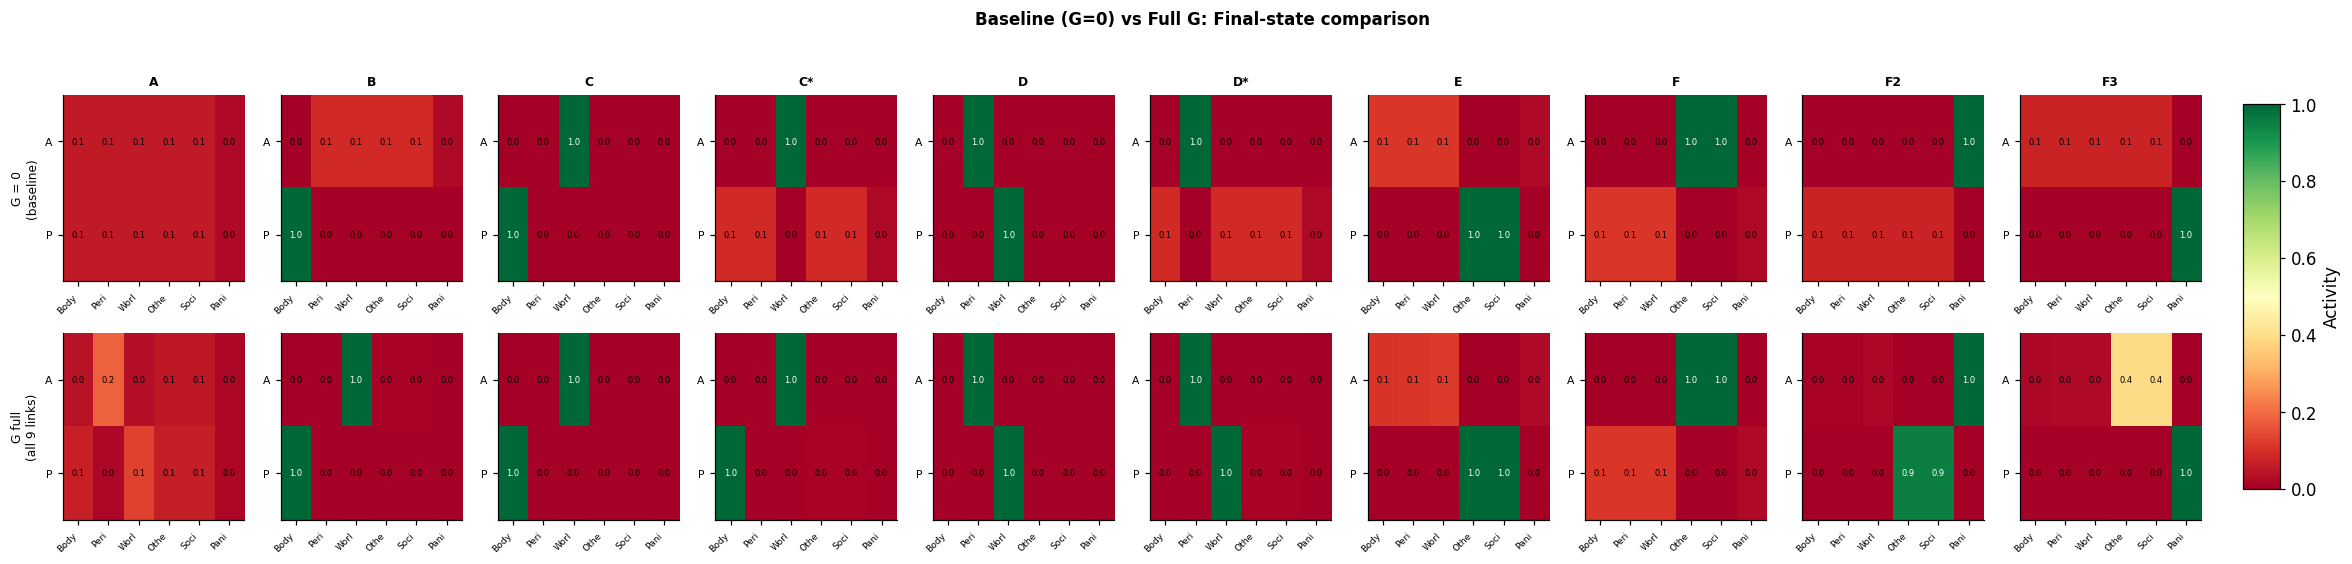



Changes introduced by each link:

Step 1: Act.World → Pas.Body (+1.0, flight→analgesia)
  → Sim C*: gained pBd

Step 2: Pas.Body → Act.World (+1.0, analgesia→escape)
  → Sim A: gained aWd pBd
  → Sim B: gained aWd

Step 3: Act.Peri → Pas.World (+1.0, orient→freeze)
  → Sim D*: gained pWd

Step 4: Pas.World → Act.Peri (+1.0, freeze→vigilance)
  → Sim A: gained aPr pWd / lost aWd pBd

Step 5: Act.Other ↔ Act.Social (+1.0, confront+vocal)
  → Sim A: lost aPr pWd

Step 6: Pas.Other ↔ Pas.Social (+1.0, submission+signal)
  → No changes to any simulation.

Step 7: Act.Panic → Act.World (+0.3, panic recruits flight)
  → Sim F2: gained pOt pSo

Step 8: Act.World → Act.Panic (+0.2, failed escape→panic)
  → No changes to any simulation.

Step 9: Act.Panic → Pas.Body (-0.5, fear-induced analgesia)
  → No changes to any simulation.


In [26]:
# ── Compact summary table ────────────────────────────────────────────────────

def short_label(on_list):
    """Compact label for active populations."""
    if not on_list:
        return "\u2014"
    parts = []
    for r, c in sorted(on_list):
        prefix = "a" if r.startswith("Act") else "p"
        col_short = {"Body/pain": "Bd", "Peripersonal risk": "Pr",
                     "World/escape": "Wd", "Other-agent": "Ot",
                     "Social field": "So", "Panic/entrapment": "Pa"}.get(c, c[:2])
        parts.append(f"{prefix}{col_short}")
    return " ".join(parts)


# Print header
header = f"{'Level':>6s}  {'Link added':>48s}"
for name in sim_names:
    header += f"  {name:>12s}"
print(header)
print("\u2500" * len(header))

for level in range(n_link_levels):
    if level == 0:
        link_desc = "(baseline G=0)"
    else:
        link_desc = G_LINK_STEPS[level-1]["label"][:48]

    row = f"{level:>6d}  {link_desc:>48s}"
    for name in sim_names:
        res = inc_results[(level, name)]
        sl = short_label(res["classify"]["on"])
        # Mark changed cells
        if level > 0 and res["on_set"] != inc_results[(level-1, name)]["on_set"]:
            sl = f"*{sl}*"
        row += f"  {sl:>12s}"
    print(row)


# ── Final comparison: baseline vs full G ─────────────────────────────────────
fig, axes = plt.subplots(2, len(sim_names), figsize=(len(sim_names) * 2.2, 5),
                         gridspec_kw={"height_ratios": [1, 1]})

for col_idx, name in enumerate(sim_names):
    for row_idx, level in enumerate([0, n_link_levels - 1]):
        ax = axes[row_idx, col_idx]
        x_f = inc_results[(level, name)]["final"]
        im = ax.imshow(x_f, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
        ax.set_xticks(range(N))
        ax.set_xticklabels(
            [COL_LABELS[i][:4] for i in range(N)], rotation=45, ha="right", fontsize=6
        )
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["A", "P"], fontsize=7)

        if row_idx == 0:
            ax.set_title(name, fontsize=8, fontweight="bold")

        # Annotate values
        for r in range(2):
            for i in range(N):
                v = x_f[r, i]
                ax.text(i, r, f"{v:.1f}", ha="center", va="center",
                        fontsize=5.5, color="white" if v > 0.6 else "black")

    # Row labels on leftmost column
    if col_idx == 0:
        axes[0, 0].set_ylabel("G = 0\n(baseline)", fontsize=8)
        axes[1, 0].set_ylabel(f"G full\n(all {len(G_LINK_STEPS)} links)", fontsize=8)

cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Activity")

fig.suptitle("Baseline (G=0) vs Full G: Final-state comparison",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()


# ── Change summary ──────────────────────────────────────────────────────────
print("\n\nChanges introduced by each link:")
print("=" * 70)
for level in range(1, n_link_levels):
    changes = []
    for name in sim_names:
        curr = inc_results[(level, name)]["on_set"]
        prev = inc_results[(level-1, name)]["on_set"]
        if curr != prev:
            added   = curr - prev
            removed = prev - curr
            desc = f"Sim {name}: "
            if added:
                desc += f"gained {short_label(added)}"
            if removed:
                desc += f"{' / ' if added else ''}lost {short_label(removed)}"
            changes.append(desc)
    print(f"\nStep {level}: {G_LINK_STEPS[level-1]['label']}")
    if changes:
        for ch in changes:
            print(f"  \u2192 {ch}")
    else:
        print(f"  \u2192 No changes to any simulation.")